**Reconhecimento de Padrões**

Grupo:

*   João
*   Marcus
* Priscilla Mayumi Tenguan

**USP - SIN5007--2026**





## Importação de Dados

Dataset escolhido: https://archive.ics.uci.edu/dataset/2/adult

In [59]:
#instalacao necessaria para ler repositorio

!pip install ucimlrepo

#essa biblioteca em geral converte valores estranhos em NaN (exemplo: ?)




[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [60]:
# Importacoes necessarias / bibliotecas
import heapq

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from imblearn.over_sampling import SMOTE
from scipy.stats import chi2_contingency, pointbiserialr
from sklearn.decomposition import PCA
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from ucimlrepo import fetch_ucirepo


In [61]:
# CÓDIGO ORIGINAL FORNECIDO:


# fetch dataset
adult = fetch_ucirepo(id=2)

# data (as pandas dataframes)
X = adult.data.features
y = adult.data.targets

# metadata
print(adult.metadata)

# variable information
print(adult.variables)


{'uci_id': 2, 'name': 'Adult', 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult', 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv', 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 48842, 'num_features': 14, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'], 'target_col': ['income'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1996, 'last_updated': 'Tue Sep 24 2024', 'dataset_doi': '10.24432/C5XW20', 'creators': ['Barry Becker', 'Ronny Kohavi'], 'intro_paper': None, 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was extracted using the fol

## Análise Exploratória dos Dados (EDA)

Único tratamento dos dados feitos no bloco: consolidação de variável target (com ponto, sem ponto)

Análises:

* Número de instâncias / feature / variável target
* definição de features (numerica, categorica)
* Missing values / duplicates / inconsistencies
* Proporção de classes na amostra
* Boxplot / Assimetria / Necessidade de tratamento (log)
* Correlation (Pearson for numerical features)




### Features: análise dos tipos de variáveis

In [62]:
#manter uma cc do df_original para posterior comparação

# Junta as features (X) e o target (y) em um único DataFrame unificado
df_original = pd.concat([X, y], axis=1)

In [63]:
# =================================================================
# INFORMAÇÕES GERAIS, VISUALIZAÇÃO E CARACTERÍSTICAS
# =================================================================

# 1. Juntar as features (X) e targets (y) num único DataFrame
df = pd.concat([X, y], axis=1)

# Pegando a quantidade de linhas e colunas
linhas = df.shape[0]
colunas = df.shape[1]

print(f"O dataset possui {linhas} linhas (instâncias) e {colunas} colunas.\n")

# 2. Features (variáveis independentes)
features = X.columns.tolist()
qtd_features = len(features)


print(f"\n São {qtd_features} features:")
for feature in features:
    print(f"- {feature}")

# 3. Listando o Target (variável dependente / classe alvo)
targets = y.columns.tolist()

print(f"\nTarget (variável dependente):")
for target in targets:
    print(f"- {target}")

print("\n--- Sample tabela ---")
display(df.head())

O dataset possui 48842 linhas (instâncias) e 15 colunas.


 São 14 features:
- age
- workclass
- fnlwgt
- education
- education-num
- marital-status
- occupation
- relationship
- race
- sex
- capital-gain
- capital-loss
- hours-per-week
- native-country

Target (variável dependente):
- income

--- Sample tabela ---


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [64]:
print("--- 1. TIPOS DE DADOS DAS FEATURES ---")
tipos_dados = df.dtypes.value_counts()
print(tipos_dados)

--- 1. TIPOS DE DADOS DAS FEATURES ---
str      9
int64    6
Name: count, dtype: int64


In [65]:
# =================================================================
# Pre-avaliacao dos tipos de variaveis dentro das features (numerico continuo / discreto ou categorico nominal / ordinal)
# =================================================================

print("--- ANÁLISE DE VARIÁVEIS ---")

for coluna in df.columns:
    n_unicos = df[coluna].nunique() # Quantos valores diferentes existem
    dtype = df[coluna].dtype       # Qual o tipo técnico (int, object, etc.)
    amostra = df[coluna].unique()[:5] # Pega 5 exemplos de valores

    print(f"Feature: {coluna}")
    print(f" - Tipo Técnico: {dtype}")
    print(f" - Valores Únicos: {n_unicos}")
    print(f" - Exemplos: {amostra}")

    # Racional de Decisão:
    if dtype == 'object':
        print(" - Classificação Sugerida: Categórica (Avaliar se é Nominal ou Ordinal)")
    elif n_unicos < 20:
        print(" - Classificação Sugerida: Numérica Discreta (ou Categórica Ordinal codificada)")
    else:
        print(" - Classificação Sugerida: Numérica Contínua")
    print("-" * 30)

--- ANÁLISE DE VARIÁVEIS ---
Feature: age
 - Tipo Técnico: int64
 - Valores Únicos: 74
 - Exemplos: [39 50 38 53 28]
 - Classificação Sugerida: Numérica Contínua
------------------------------
Feature: workclass
 - Tipo Técnico: str
 - Valores Únicos: 9
 - Exemplos: <StringArray>
['State-gov', 'Self-emp-not-inc', 'Private', 'Federal-gov', 'Local-gov']
Length: 5, dtype: str
 - Classificação Sugerida: Numérica Discreta (ou Categórica Ordinal codificada)
------------------------------
Feature: fnlwgt
 - Tipo Técnico: int64
 - Valores Únicos: 28523
 - Exemplos: [ 77516  83311 215646 234721 338409]
 - Classificação Sugerida: Numérica Contínua
------------------------------
Feature: education
 - Tipo Técnico: str
 - Valores Únicos: 16
 - Exemplos: <StringArray>
['Bachelors', 'HS-grad', '11th', 'Masters', '9th']
Length: 5, dtype: str
 - Classificação Sugerida: Numérica Discreta (ou Categórica Ordinal codificada)
------------------------------
Feature: education-num
 - Tipo Técnico: int64
 - V

### Tratamento Variável Target (income)

In [66]:
# =================================================================
# BLOCO: PADRONIZAÇÃO DA VARIÁVEL ALVO (TARGET)
# =================================================================

print("--- TRATAMENTO DA VARIÁVEL ALVO (INCOME) ---\n")

print("1. Contagem de classes ANTES da limpeza:")
print(df['income'].value_counts())

# A transformação:
# 1. Garante que é texto (str)
# 2. Substitui o ponto final por nada (remove)
# 3. Remove espaços em branco sobrando no início ou fim (strip)
df['income'] = df['income'].astype(str).str.replace('.', '', regex=False).str.strip()

print("\n" + "-" * 40 + "\n")

print("2. Contagem de classes APÓS a limpeza:")
print(df['income'].value_counts())

--- TRATAMENTO DA VARIÁVEL ALVO (INCOME) ---

1. Contagem de classes ANTES da limpeza:
income
<=50K     24720
<=50K.    12435
>50K       7841
>50K.      3846
Name: count, dtype: int64

----------------------------------------

2. Contagem de classes APÓS a limpeza:
income
<=50K    37155
>50K     11687
Name: count, dtype: int64


In [67]:
print("### Classificação das Variáveis ###\n")

# 1. Initialize three empty lists
continuas_razao = []
discretas_ordinais = []
discretas_nominais = []

# 2. Iterate through each feature and classify them
for feature in df.columns:
    if feature in ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week']:
        continuas_razao.append(feature)
    elif feature in ['education-num', 'education']:
        discretas_ordinais.append(feature)
    elif feature in ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']:
        discretas_nominais.append(feature)
    else:
        print(f"Warning: Feature '{feature}' not classified.")

# Print the classified features
print("Contínuas (Razão):")
for f in continuas_razao:
    print(f"- {f}")

print("\nDiscretas Ordinais:")
for f in discretas_ordinais:
    print(f"- {f}")

print("\nDiscretas Nominais:")
for f in discretas_nominais:
    print(f"- {f}")

### Classificação das Variáveis ###

Contínuas (Razão):
- age
- fnlwgt
- capital-gain
- capital-loss
- hours-per-week

Discretas Ordinais:
- education
- education-num

Discretas Nominais:
- workclass
- marital-status
- occupation
- relationship
- race
- sex
- native-country
- income


### Missing values / duplicates / inconsistencies

In [68]:
# =================================================================
# ANÁLISE QUANTITATIVA DE MISSING VALUES
# =================================================================

print("--- ANÁLISE DE DADOS AUSENTES E ANOMALIAS ---")

# 1. Cálculos de base
total_instancias = df.shape[0]
num_instances_with_missing = df.isnull().any(axis=1).sum()
pct_instances_missing = (num_instances_with_missing / total_instancias) * 100

print(f"Total de instâncias no dataset: {total_instancias}")
print(f"Instâncias com missing values (em qualquer posição): {num_instances_with_missing}")
print(f"Percentual de instâncias incompletas: {pct_instances_missing:.2f}%\n")

# 2. Criando um resumo por coluna (Merging Trecho 1 + Porcentagem)
# Criamos um DataFrame temporário para mostrar os dados lado a lado
resumo_missing = pd.DataFrame({
    'Total Missing': df.isnull().sum(),
    '% do Total': (df.isnull().sum() / total_instancias) * 100
})

# Ordenar para mostrar o que falta mais no topo (racional do Trecho 1)
resumo_missing = resumo_missing.sort_values(by='Total Missing', ascending=False)

print("Resumo de Missing Values por Feature (apenas com dados ausentes):")
# Filtramos para mostrar apenas quem tem Missing > 0, evitando poluição
print(resumo_missing[resumo_missing['Total Missing'] > 0])

# 3. Investigação de Categorias (Racional do Trecho 2 - Focado)
print("\n--- DETALHAMENTO DE FREQUÊNCIA (ANOMALIAS) ---")
# Vamos olhar apenas as colunas de texto que possuem missing values
colunas_com_problema = resumo_missing[resumo_missing['Total Missing'] > 0].index.tolist()

for coluna in colunas_com_problema:
    if df[coluna].dtype == 'object':
        print(f"\nFeature: '{coluna}'")
        # Mostra os valores e inclui o NaN (que pode ser o antigo '?')
        print(df[coluna].value_counts(dropna=False))
        print("-" * 40)

--- ANÁLISE DE DADOS AUSENTES E ANOMALIAS ---
Total de instâncias no dataset: 48842
Instâncias com missing values (em qualquer posição): 1221
Percentual de instâncias incompletas: 2.50%

Resumo de Missing Values por Feature (apenas com dados ausentes):
                Total Missing  % do Total
occupation                966    1.977806
workclass                 963    1.971664
native-country            274    0.560993

--- DETALHAMENTO DE FREQUÊNCIA (ANOMALIAS) ---


In [69]:
# =================================================================
# BLOCO 1: IDENTIFICAÇÃO DE DUPLICATAS EXATAS
# =================================================================
num_dups = df.duplicated().sum()
pct_dups = (num_dups / len(df)) * 100

print(f"Número de registros exatamente duplicados: {num_dups}")
print(f"Impacto percentual: {pct_dups:.2f}%")

Número de registros exatamente duplicados: 48
Impacto percentual: 0.10%


In [70]:
# =================================================================
# BLOCO: AUDITORIA DE INTEGRIDADE E DETALHAMENTO DE CONFLITOS
# =================================================================

# 1. Definição das variáveis preditoras (as 14 colunas de características)
features_preditoras = list(df.columns.drop('income'))

# 2. Identificação de todas as instâncias com características idênticas
df_clones = df[df.duplicated(subset=features_preditoras, keep=False)]

# 3. Agrupamento para localizar divergências na variável alvo (income)
agrupamento_conflitos = df_clones.groupby(features_preditoras)['income'].nunique()
perfis_com_erro = agrupamento_conflitos[agrupamento_conflitos > 1].index

# 4. Cálculo de métricas para o Resumo Inicial
total_perfis_erro = len(perfis_com_erro)
total_linhas_afetadas = df_clones[df_clones.set_index(features_preditoras).index.isin(perfis_com_erro)].shape[0]
percentual_impacto = (total_linhas_afetadas / len(df)) * 100

# --- EXIBIÇÃO DO RESUMO ---
print("--- RESUMO DE INCONSISTÊNCIA DE RÓTULOS (LABEL NOISE) ---")
print(f"Número de perfis com classificações conflitantes: {total_perfis_erro}")
print(f"Total de instâncias afetadas: {total_linhas_afetadas}")
print(f"Percentual de inconsistência no dataset: {percentual_impacto:.4f}%")
print("\n" + "="*80 + "\n")

# --- EXIBIÇÃO DO DETALHAMENTO ---
print(f"--- DETALHAMENTO DOS {total_perfis_erro} PERFIS IDENTIFICADOS ---\n")

for i, perfil in enumerate(perfis_com_erro, 1):
    print(f"PERFIL CONFLITANTE #{i}:")

    # Filtro para isolar as linhas que compõem este perfil específico
    filtro = True
    for col, val in zip(features_preditoras, perfil):
        filtro &= (df[col] == val)

    # Exibição das linhas idênticas para comparação do campo 'income'
    df_visualizacao = df[filtro]
    display(df_visualizacao[features_preditoras + ['income']])
    print("-" * 80 + "\n")

print("Nota técnica: Os perfis listados acima apresentam entropia na variável alvo, representando registros contraditórios para o treinamento de modelos preditivos.")

--- RESUMO DE INCONSISTÊNCIA DE RÓTULOS (LABEL NOISE) ---
Número de perfis com classificações conflitantes: 5
Total de instâncias afetadas: 10
Percentual de inconsistência no dataset: 0.0205%


--- DETALHAMENTO DOS 5 PERFIS IDENTIFICADOS ---

PERFIL CONFLITANTE #1:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
29506,34,Private,169583,Masters,14,Never-married,Exec-managerial,Not-in-family,White,Female,0,0,50,United-States,<=50K
34934,34,Private,169583,Masters,14,Never-married,Exec-managerial,Not-in-family,White,Female,0,0,50,United-States,>50K


--------------------------------------------------------------------------------

PERFIL CONFLITANTE #2:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
848,39,Private,138192,Bachelors,13,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,<=50K
22761,39,Private,138192,Bachelors,13,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,>50K


--------------------------------------------------------------------------------

PERFIL CONFLITANTE #3:


...

--------------------------------------------------------------------------------

PERFIL CONFLITANTE #4:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
10929,46,Private,224559,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,Black,Male,0,0,40,United-States,<=50K
48363,46,Private,224559,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,Black,Male,0,0,40,United-States,>50K


--------------------------------------------------------------------------------

PERFIL CONFLITANTE #5:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
16683,46,Private,235646,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,>50K
34342,46,Private,235646,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,<=50K


--------------------------------------------------------------------------------

Nota técnica: Os perfis listados acima apresentam entropia na variável alvo, representando registros contraditórios para o treinamento de modelos preditivos.


### Proporção classes da amostra

--- DISTRIBUIÇÃO UNIFICADA DAS CLASSES ---
        Quantidade  Proporção (%)
income                           
<=50K        37155      76.071823
>50K         11687      23.928177


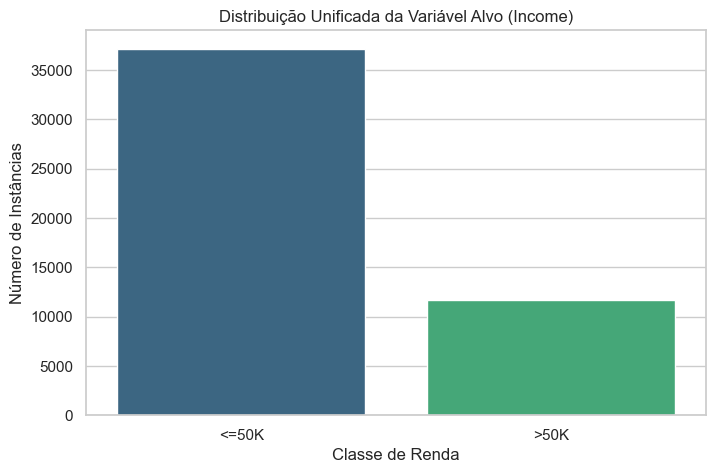

In [71]:
# =================================================================
# BLOCO: ANÁLISE DA PROPORÇÃO DAS CLASSES
# =================================================================

# # 1. Limpeza: Remover pontos finais e espaços extras das classes
y_limpo = y.iloc[:, 0].astype(str).str.replace('.', '', regex=False).str.strip()

# 2. Contagem e Porcentagem
contagem_classes = y_limpo.value_counts()
porcentagem_classes = y_limpo.value_counts(normalize=True) * 100

resumo_classes = pd.DataFrame({
    'Quantidade': contagem_classes,
    'Proporção (%)': porcentagem_classes
})

print("--- DISTRIBUIÇÃO UNIFICADA DAS CLASSES ---")
print(resumo_classes)

# 3. Gráfico atualizado para evitar o DeprecationWarning

plt.figure(figsize=(8, 5))

# O ajuste: atribuímos y_limpo ao 'x' E ao 'hue', e desativamos a legenda
sns.countplot(x=y_limpo, hue=y_limpo, palette='viridis', legend=False)

plt.title('Distribuição Unificada da Variável Alvo (Income)')
plt.ylabel('Número de Instâncias')
plt.xlabel('Classe de Renda')
plt.show()

### Boxplots para Identificação de Outliers em Colunas Numéricas / Assimetria

--- IDENTIFICAÇÃO DE OUTLIERS (MÉTODO DE TUKEY / IQR) ---

Resumo Quantitativo de Outliers por Feature:
- age: 216 outliers detectados (0.44% da base)
- fnlwgt: 1453 outliers detectados (2.97% da base)
- capital-gain: 4035 outliers detectados (8.26% da base)
- capital-loss: 2282 outliers detectados (4.67% da base)
- hours-per-week: 13496 outliers detectados (27.63% da base)

------------------------------------------------------------



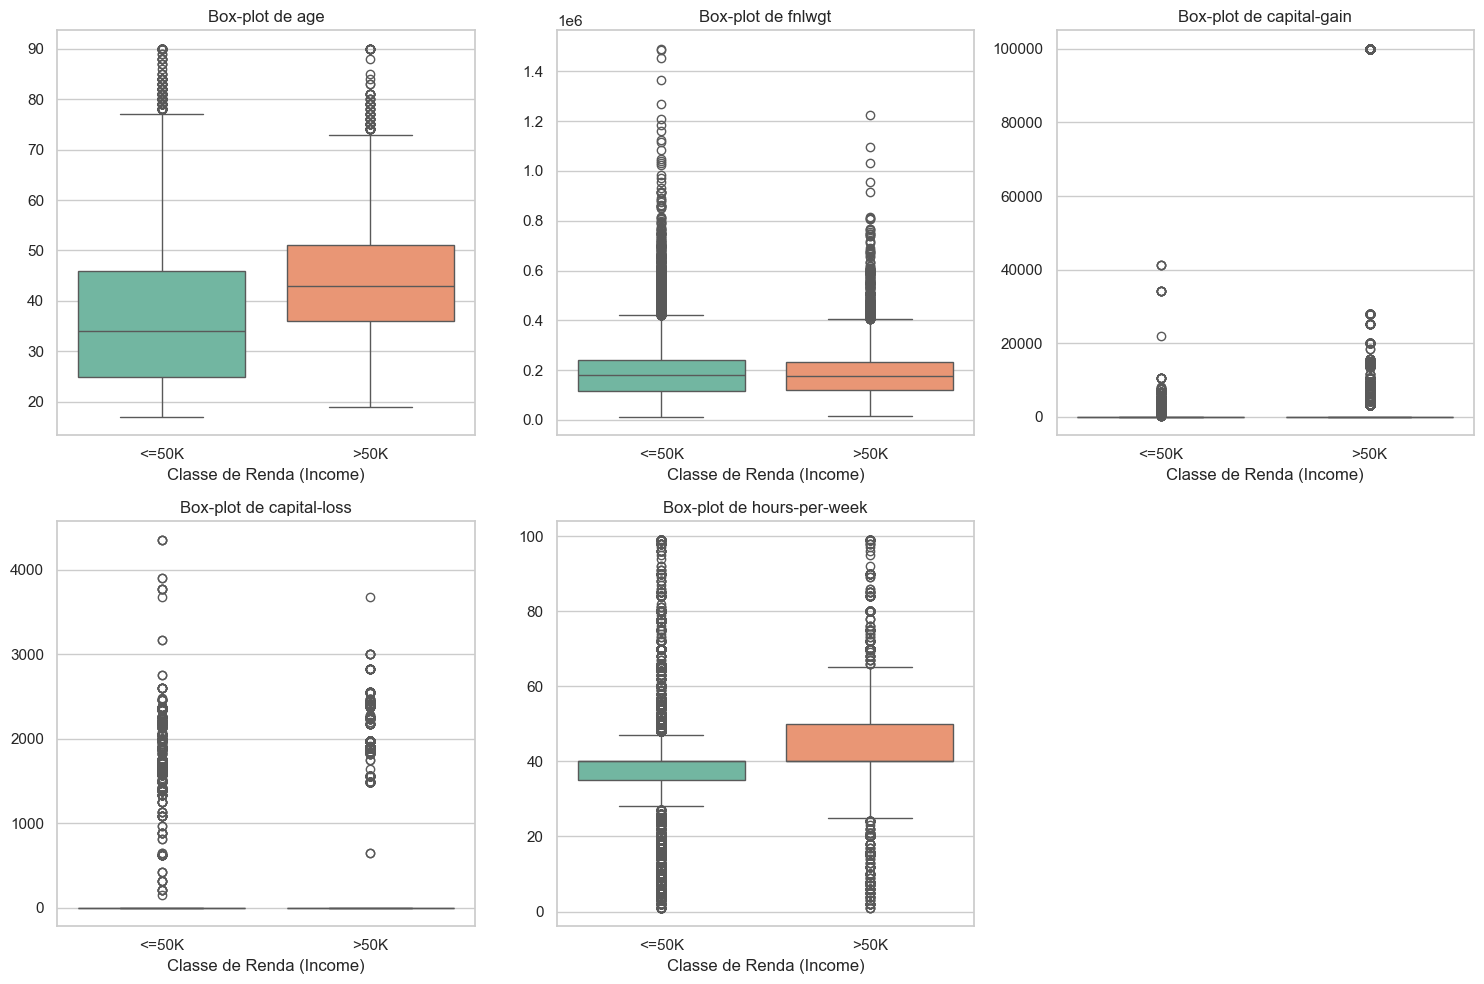

In [72]:
# =================================================================
# BLOCO: ANÁLISE DE OUTLIERS (VISUAL E QUANTITATIVA) - Box-plot
# =================================================================

print("--- IDENTIFICAÇÃO DE OUTLIERS (MÉTODO DE TUKEY / IQR) ---\n")

# 1. IDENTIFICAÇÃO QUANTITATIVA
print("Resumo Quantitativo de Outliers por Feature:")
for col in continuas_razao:
    # Fórmulas slide da materia (+/- 1.5 IQR = Q3-Q1)
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Encontrando quem está fora dos limites (bolinhas no gráfico)
    outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]
    pct_outliers = (len(outliers) / len(df)) * 100

    print(f"- {col}: {len(outliers)} outliers detectados ({pct_outliers:.2f}% da base)")

print("\n" + "-" * 60 + "\n")

# 2. IDENTIFICAÇÃO VISUAL (Box-plots cruzados com a Variável Alvo)
# Usando a sua estrutura original de subplots (ajustado para 2 linhas e 3 colunas)
plt.figure(figsize=(15, 10))

for i, col in enumerate(continuas_razao):
    plt.subplot(2, 3, i + 1) # Cria o grid de gráficos

    # Boxplot separado por classe de renda (income) para mostrar relação bivariada
    sns.boxplot(x=df['income'], y=df[col], hue=df['income'], palette='Set2', legend=False)

    plt.title(f'Box-plot de {col}')
    plt.ylabel('') # Removendo y-label para evitar poluição visual
    plt.xlabel('Classe de Renda (Income)')

plt.tight_layout()
plt.show()


# # Gerar boxplots para as colunas numéricas contínuas
# plt.figure(figsize=(15, 10))

# # 'continuas_razao' was identified as the list of continuous numerical features
# for i, col in enumerate(continuas_razao):
#     plt.subplot(2, 3, i + 1) # Adjust subplot grid as needed based on number of features
#     sns.boxplot(y=df[col])
#     plt.title(f'Boxplot de {col}')
#     plt.ylabel('') # Remove y-label to avoid clutter

# plt.tight_layout()
# plt.show()

In [73]:
# =================================================================
# BLOCO: ANÁLISE DE TENDÊNCIA CENTRAL E ASSIMETRIA (SKEWNESS)
# =================================================================

# 1. Identificação das colunas numéricas do dataset
colunas_numericas = df.select_dtypes(include=['int64', 'float64']).columns

# 2. Cálculo das métricas de tendência central e assimetria
relatorio_estatistico = pd.DataFrame({
    'Média': df[colunas_numericas].mean(),
    'Mediana': df[colunas_numericas].median(),
    'Skewness': df[colunas_numericas].skew()
})

# 3. Lógica de interpretação baseada nos intervalos de Bulmer (1979)
def classificar_assimetria(valor):
    valor_abs = abs(valor)
    if valor_abs < 0.5:
        return "Suficientemente Simétrica"
    elif 0.5 <= valor_abs <= 1.0:
        return "Assimetria Moderada"
    else:
        return "Assimetria Severa / Altamente Assimétrica"

relatorio_estatistico['Classificação'] = relatorio_estatistico['Skewness'].apply(classificar_assimetria)

# 4. Exibição dos resultados consolidados
print("--- TENDÊNCIA CENTRAL E ASSIMETRIA ---")
display(relatorio_estatistico.sort_values(by='Skewness', ascending=False))

# 5. Referências e notas técnicas
print("\n" + "="*80)
print("REFERÊNCIA PARA INTERPRETAÇÃO (SKEWNESS):")
print("Bulmer, M. G. (1979). Principles of Statistics. Dover Publications.")
print("-" * 80)
print("Nota Técnica: Distribuições com assimetria severa (|S| > 1) indicam que a média")
print("não representa adequadamente o centro dos dados devido ao impacto de outliers,")
print("justificando o uso de escalas logarítmicas ou análises via histogramas/KDE.")
print("="*80)

--- TENDÊNCIA CENTRAL E ASSIMETRIA ---


,Média,Mediana,Skewness,Classificação
capital-gain,1079.067626,0.0,11.894659,Assimetria Severa / Altamente Assimétrica
capital-loss,87.502314,0.0,4.569809,Assimetria Severa / Altamente Assimétrica
fnlwgt,189664.134597,178144.5,1.438892,Assimetria Severa / Altamente Assimétrica
age,38.643585,37.0,0.557580,Assimetria Moderada
hours-per-week,40.422382,40.0,0.238750,Suficientemente Simétrica
education-num,10.078089,10.0,-0.316525,Suficientemente Simétrica



REFERÊNCIA PARA INTERPRETAÇÃO (SKEWNESS):
Bulmer, M. G. (1979). Principles of Statistics. Dover Publications.
--------------------------------------------------------------------------------
Nota Técnica: Distribuições com assimetria severa (|S| > 1) indicam que a média
não representa adequadamente o centro dos dados devido ao impacto de outliers,
justificando o uso de escalas logarítmicas ou análises via histogramas/KDE.


--- ANÁLISE DE DISTRIBUIÇÃO: ESCALA ORIGINAL VS. LOGARÍTMICA ---



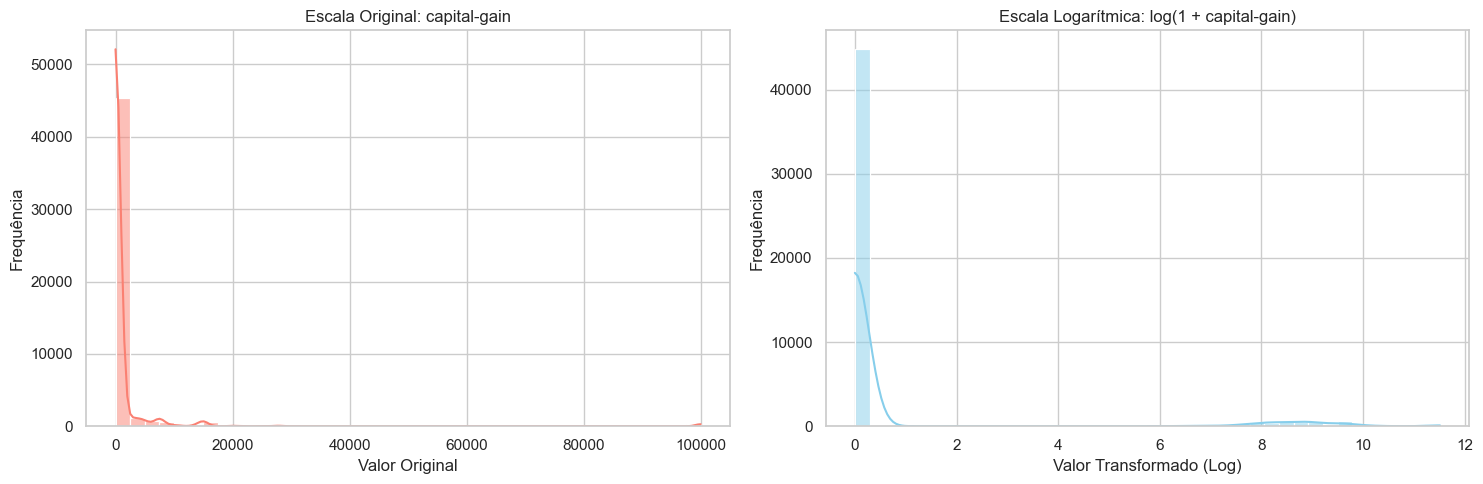

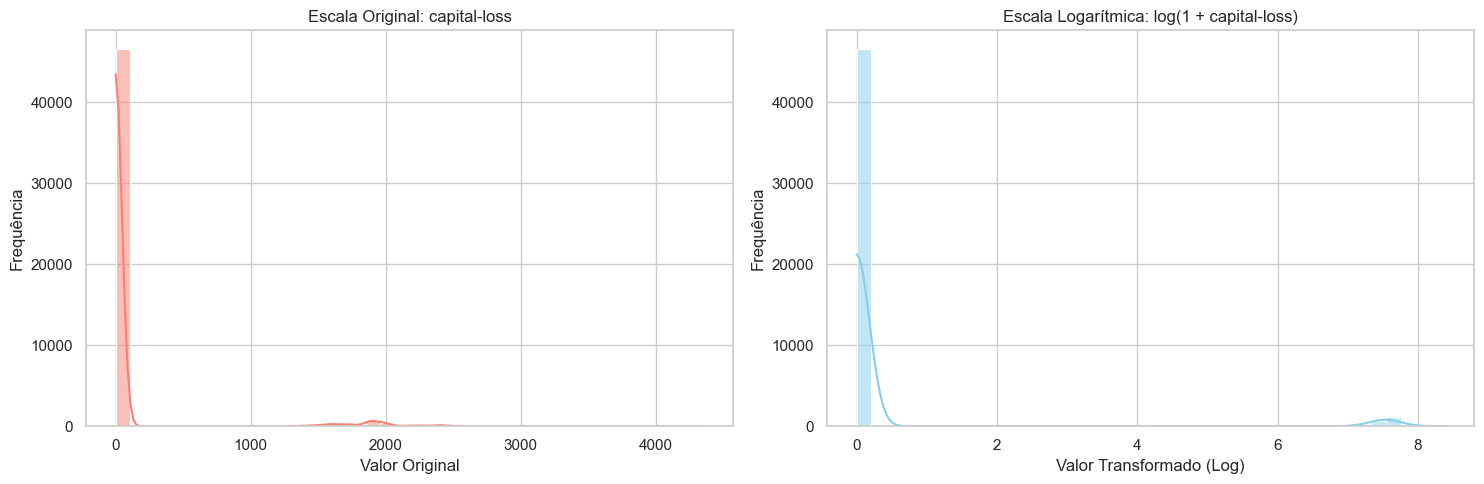

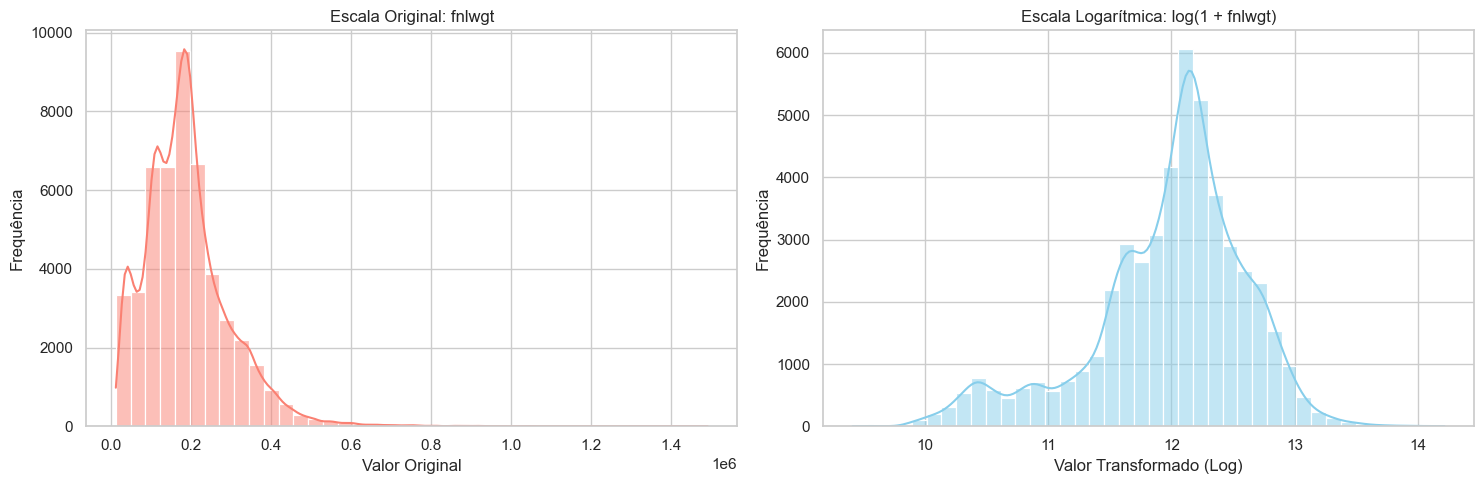

Nota Técnica: A transformação np.log1p foi utilizada para evitar erros matemáticos com valores iguais a zero (log de 0 é indefinido).


In [74]:
# =================================================================
# BLOCO: ANÁLISE COMPARATIVA DE DISTRIBUIÇÕES (LINEAR VS. LOG)
# =================================================================

# Variáveis identificadas com assimetria severa (|S| > 1)
cols_assimetria_severa = ['capital-gain', 'capital-loss', 'fnlwgt']

print("--- ANÁLISE DE DISTRIBUIÇÃO: ESCALA ORIGINAL VS. LOGARÍTMICA ---\n")

for coluna in cols_assimetria_severa:
    # Criação de figura com 2 subplots lado a lado
    fig, eixos = plt.subplots(1, 2, figsize=(15, 5))

    # -------------------------------------------------------------
    # Gráfico 1: Escala Original (Linear)
    # -------------------------------------------------------------
    sns.histplot(df[coluna], kde=True, bins=40, color='salmon', ax=eixos[0])
    eixos[0].set_title(f'Escala Original: {coluna}')
    eixos[0].set_xlabel('Valor Original')
    eixos[0].set_ylabel('Frequência')

    # -------------------------------------------------------------
    # Gráfico 2: Escala Logarítmica (Log1p para lidar com zeros)
    # -------------------------------------------------------------
    # Aplicação de np.log1p(x) que equivale a log(1 + x)
    dados_log = np.log1p(df[coluna])

    sns.histplot(dados_log, kde=True, bins=40, color='skyblue', ax=eixos[1])
    eixos[1].set_title(f'Escala Logarítmica: log(1 + {coluna})')
    eixos[1].set_xlabel('Valor Transformado (Log)')
    eixos[1].set_ylabel('Frequência')

    plt.tight_layout()
    plt.show()

print("Nota Técnica: A transformação np.log1p foi utilizada para evitar erros matemáticos com valores iguais a zero (log de 0 é indefinido).")

Outputs da análise de assimetria + tratamento com log

fnlwgt: trocar por log torna a distribuição mais próxima de distribuição normal
capital-gain e capital-loss: trocar por log torna os valores mais próximos da escala das outras variáveis

### Correlation for Numerical Features

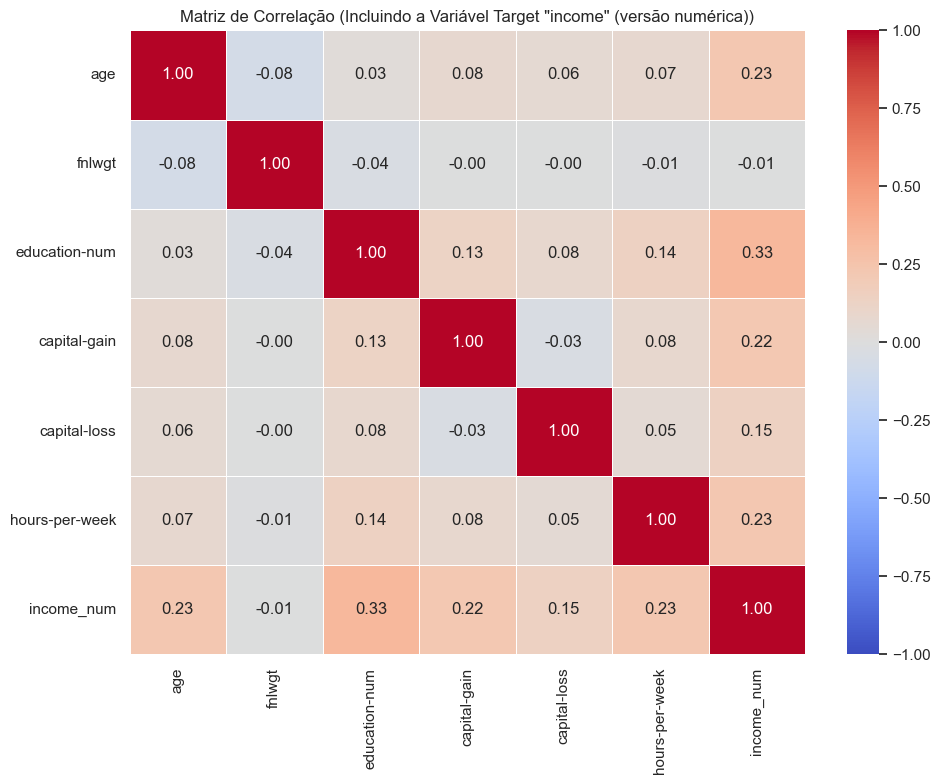

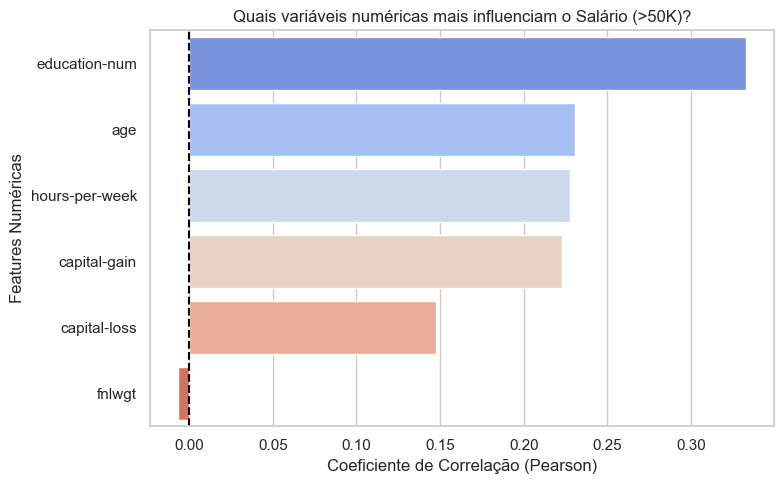

In [75]:
# =================================================================
# BLOCO: ANÁLISE DE CORRELAÇÃO Pearson
# =================================================================

# 1. Cópia df para analise de correl
df_corr = df.copy()

# 2. Tratamento do Target: Transformar 'income' em 0 e 1
# tratamento dos pontos, caso ainda existam (income)
df_corr['income'] = df_corr['income'].astype(str).str.replace('.', '', regex=False).str.strip()
df_corr['income_num'] = df_corr['income'].map({'<=50K': 0, '>50K': 1})

# 3. Selecionar apenas colunas numéricas + novo target numérico
colunas_numericas = df_corr.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 4. Calcular a Matriz de Correlação
correlation_matrix = df_corr[colunas_numericas].corr()

# 5. Visualização 1: Heatmap Tradicional
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlação (Incluindo a Variável Target "income" (versão numérica))')
plt.tight_layout()
plt.show()

# ==========================================
# ADICIONANDO ESPAÇO ENTRE OS GRÁFICOS
print("\n" * 2) # Pula duas linhas em branco
# ==========================================

# 6. matrix correl - heatmap
plt.figure(figsize=(8, 5))

# Pega a correlação de todo mundo APENAS com o income_num, remove o próprio income_num, e ordena
corr_target = correlation_matrix['income_num'].drop('income_num').sort_values(ascending=False)

# Criando o gráfico de barras (ordenado)
sns.barplot(
    x=corr_target.values,
    y=corr_target.index,
    hue=corr_target.index,
    palette='coolwarm',
    legend=False
)

plt.title('Quais variáveis numéricas mais influenciam o Salário (>50K)?')
plt.xlabel('Coeficiente de Correlação (Pearson)')
plt.ylabel('Features Numéricas')
plt.axvline(x=0, color='black', linestyle='--') # Linha do zero indicando correlação neutra
plt.tight_layout()
plt.show()

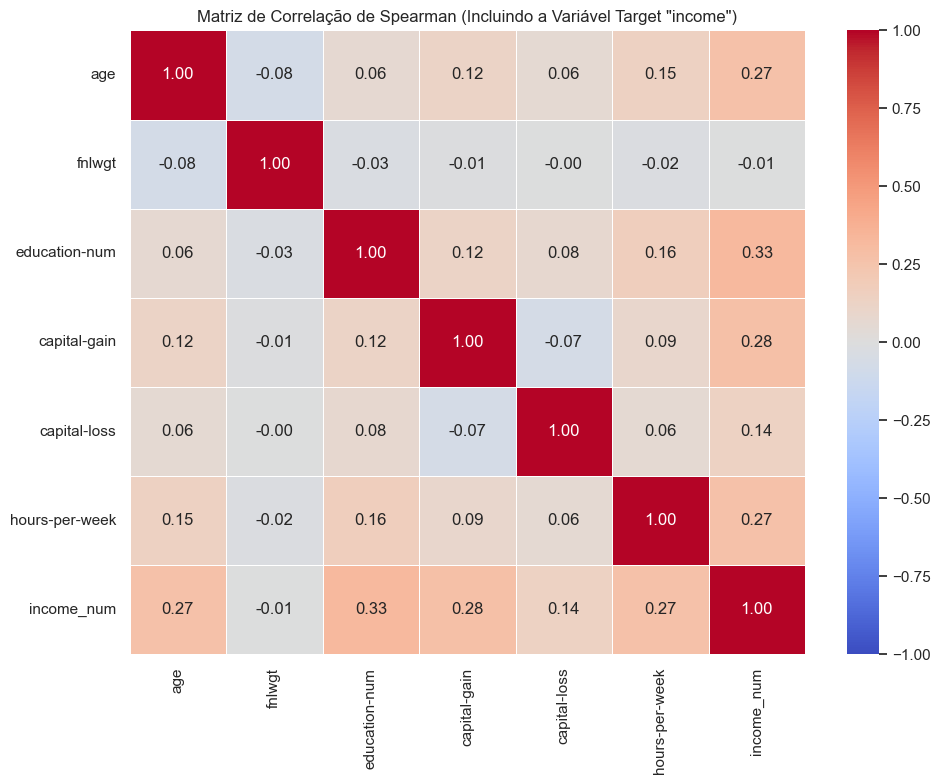

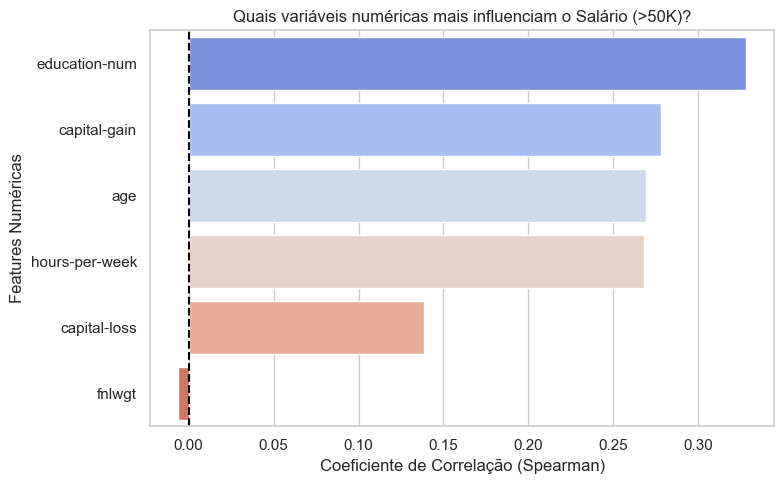

In [76]:
# =================================================================
# BLOCO: MATRIZ DE CORRELAÇÃO DE SPEARMAN
# =================================================================

# 1. Cópia df para analise de correl
df_corr = df.copy()

# 2. Tratamento do Target: Transformar 'income' em 0 e 1
# tratamento dos pontos, caso ainda existam (income)
df_corr['income'] = df_corr['income'].astype(str).str.replace('.', '', regex=False).str.strip()
df_corr['income_num'] = df_corr['income'].map({'<=50K': 0, '>50K': 1})

# 3. Selecionar apenas colunas numéricas + novo target numérico
colunas_numericas = df_corr.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 4. Calcular a Matriz de Correlação (Usando Spearman)
correlation_matrix = df_corr[colunas_numericas].corr(method='spearman')

# 5. Visualização 1: Heatmap Tradicional
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlação de Spearman (Incluindo a Variável Target "income")')
plt.tight_layout()
plt.show()

# ==========================================
# ADICIONANDO ESPAÇO ENTRE OS GRÁFICOS
print("\n" * 2) # Pula duas linhas em branco
# ==========================================

# 6. matrix correl - heatmap (Ranking focado no Target)
plt.figure(figsize=(8, 5))

# Pega a correlação de todo mundo APENAS com o income_num, remove o próprio income_num, e ordena
corr_target = correlation_matrix['income_num'].drop('income_num').sort_values(ascending=False)

# Criando o gráfico de barras (ordenado)
sns.barplot(
    x=corr_target.values,
    y=corr_target.index,
    hue=corr_target.index,
    palette='coolwarm',
    legend=False
)

plt.title('Quais variáveis numéricas mais influenciam o Salário (>50K)?')
plt.xlabel('Coeficiente de Correlação (Spearman)') # Eixo atualizado
plt.ylabel('Features Numéricas')
plt.axvline(x=0, color='black', linestyle='--') # Linha do zero indicando correlação neutra
plt.tight_layout()
plt.show()

### Variáveis categóricas - Histogramas

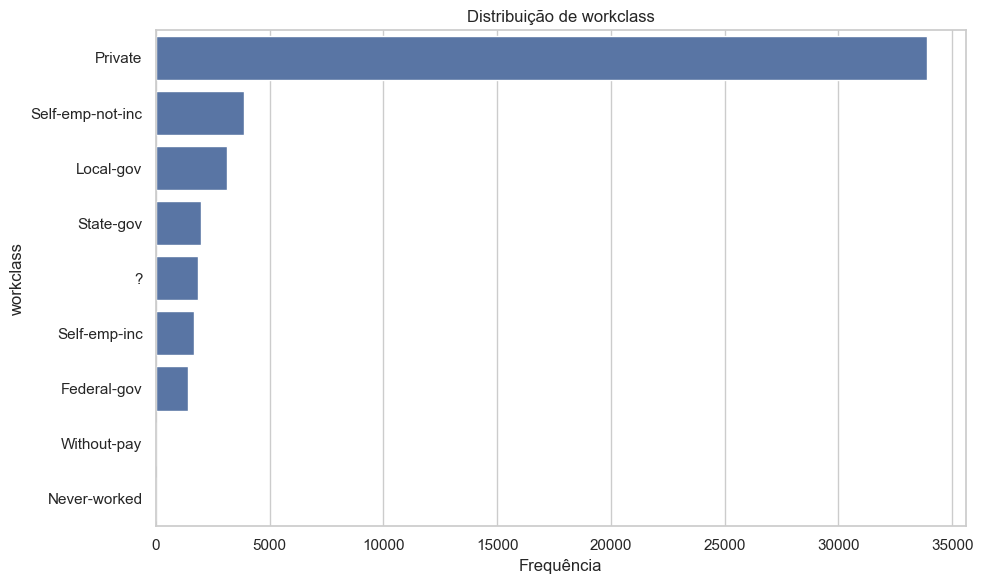

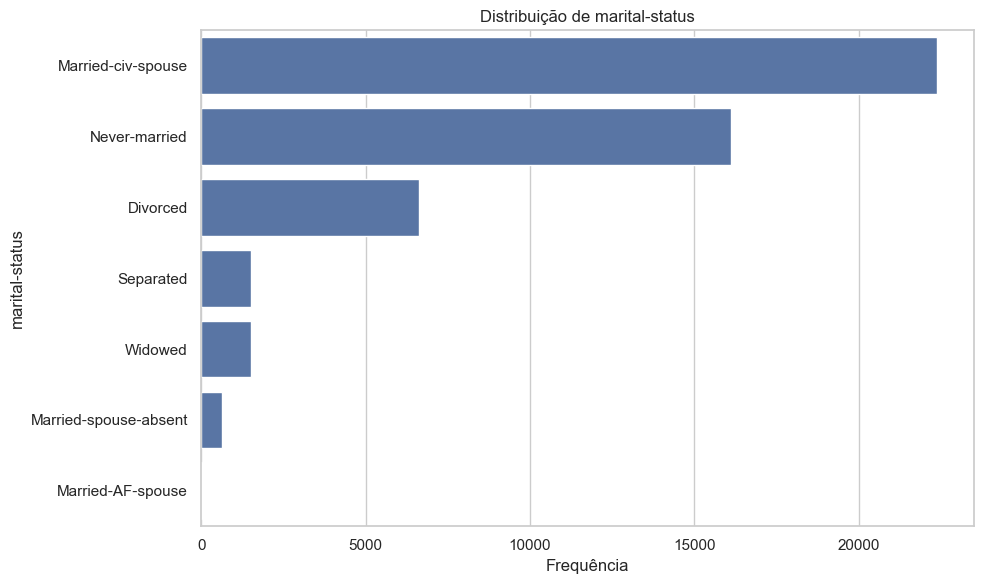

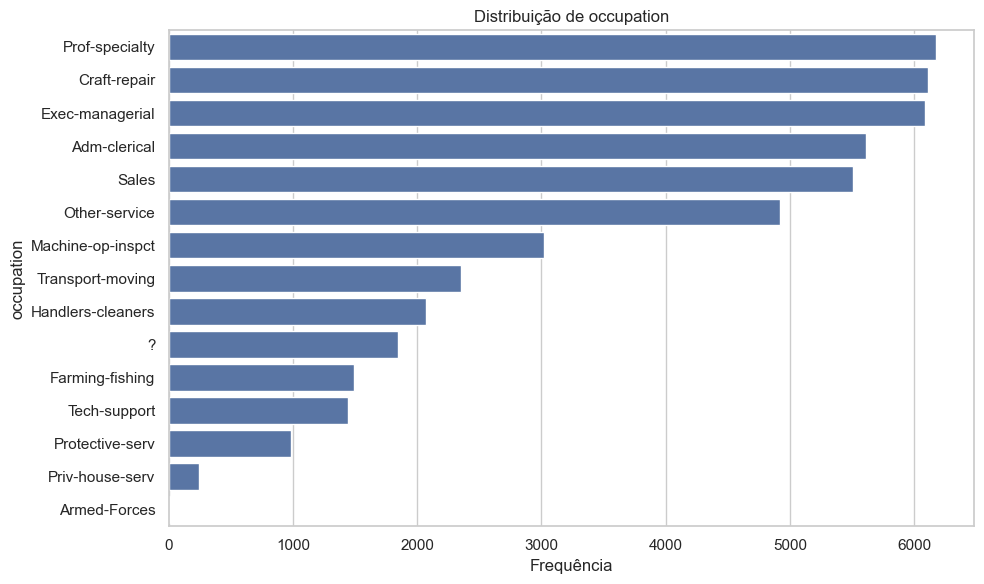

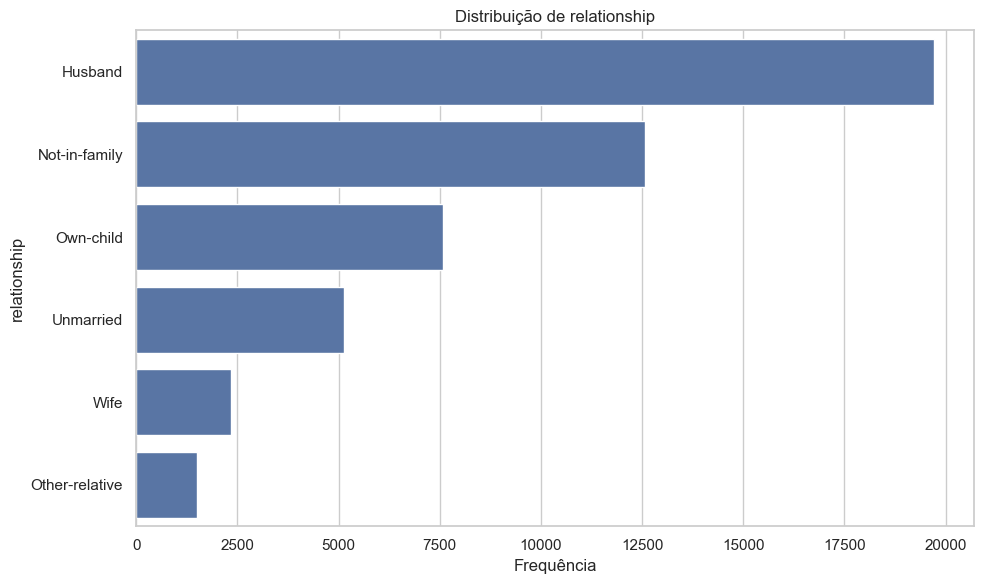

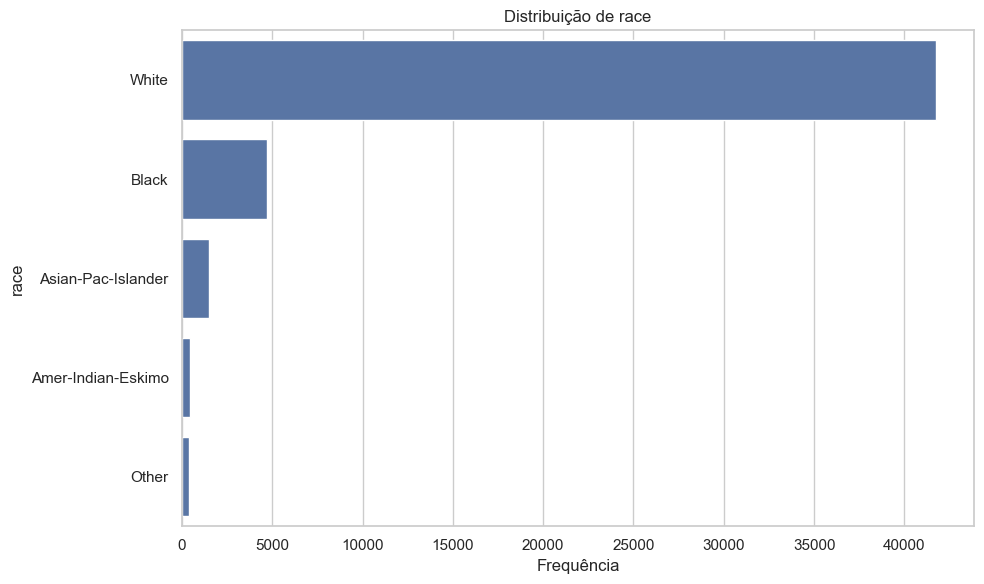

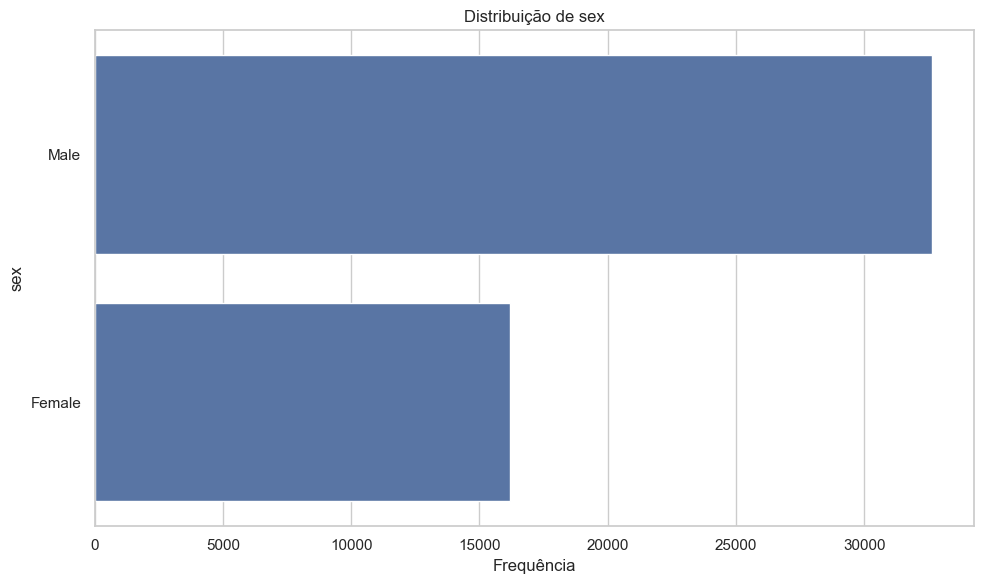

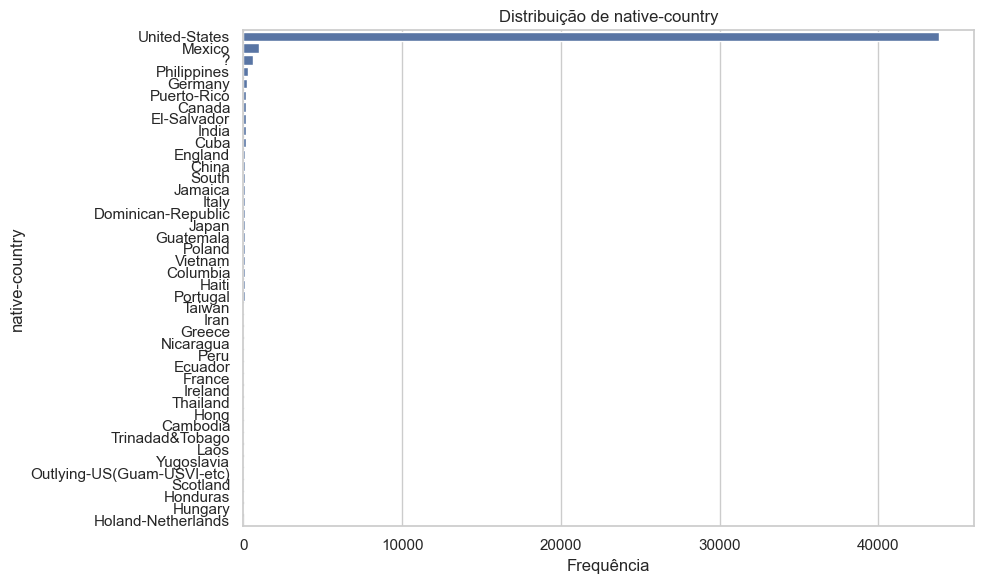

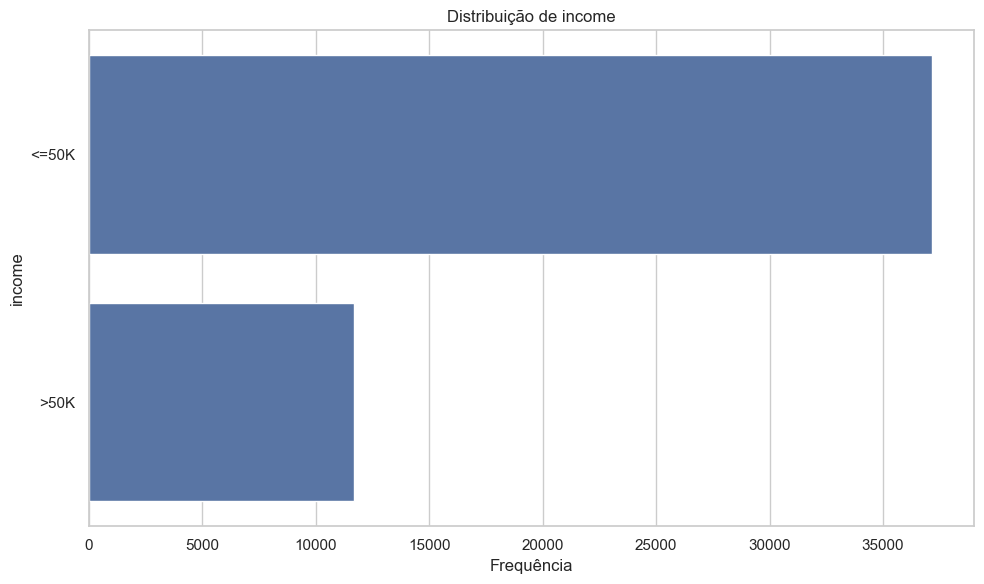

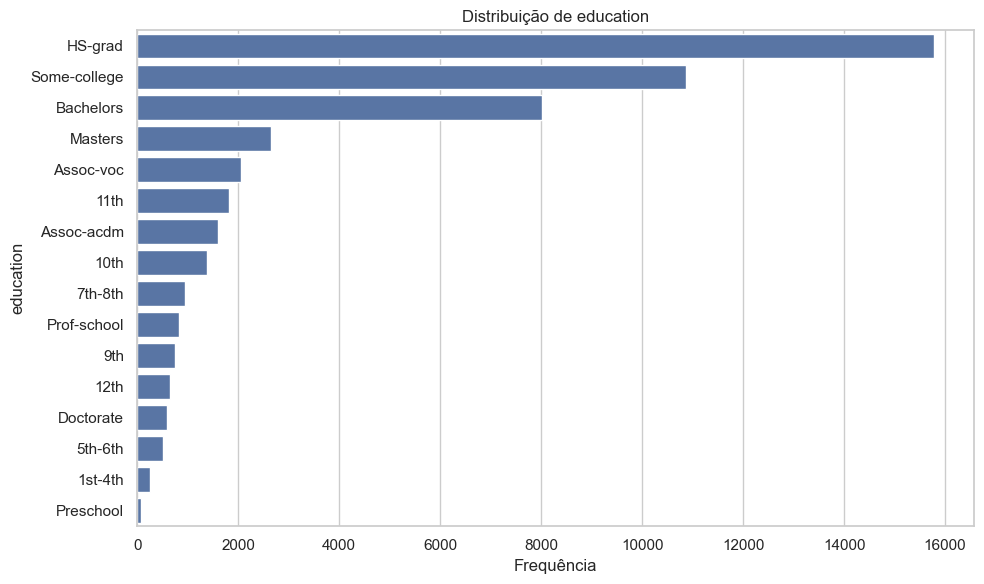

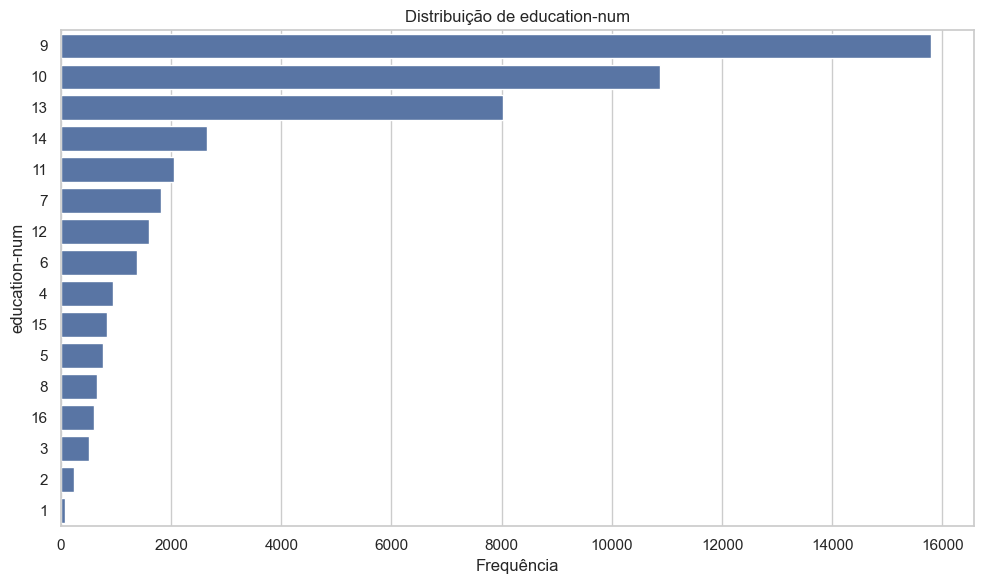

In [77]:
# Histogramas das variáveis categóricas (nominais e ordinais)
cat_cols = discretas_nominais + discretas_ordinais
for col in cat_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, y=col, order=df[col].value_counts().index)
    plt.title(f'Distribuição de {col}')
    plt.xlabel('Frequência')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

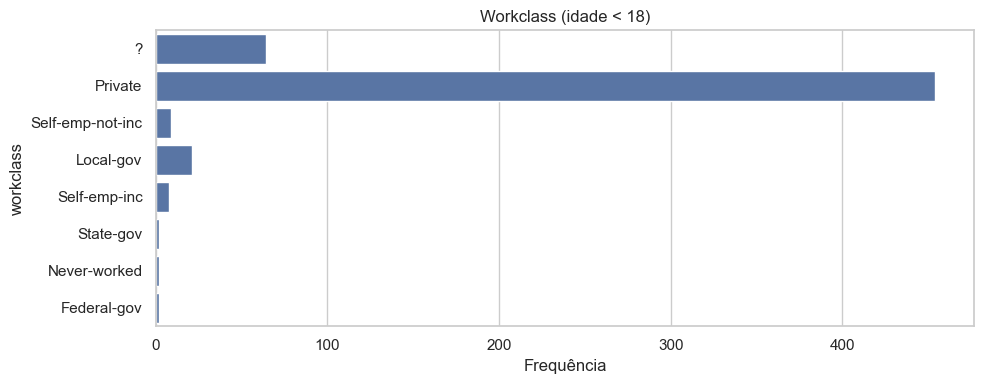

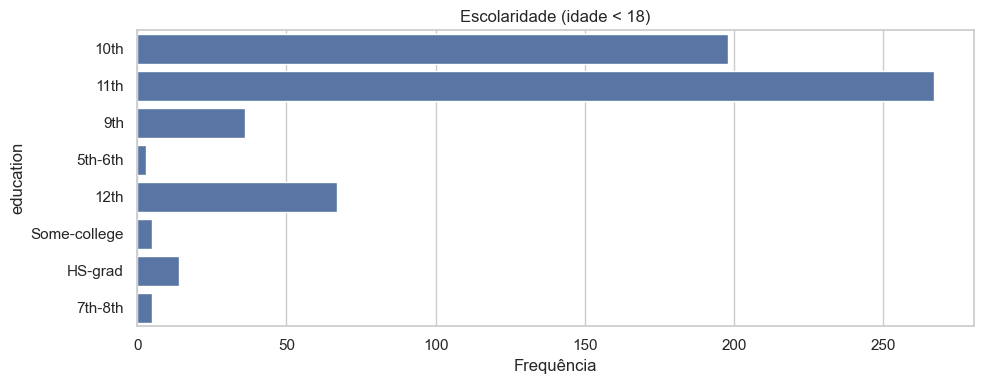

In [78]:
# Workclass e escolaridade para pessoas com menos de 18 anos
u18 = df[df['age'] < 18]

plt.figure(figsize=(10, 4))
sns.countplot(data=u18, y='workclass')
plt.title('Workclass (idade < 18)')
plt.xlabel('Frequência')
plt.ylabel('workclass')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.countplot(data=u18, y='education')
plt.title('Escolaridade (idade < 18)')
plt.xlabel('Frequência')
plt.ylabel('education')
plt.tight_layout()
plt.show()

In [79]:
# Valores únicos em colunas categóricas selecionadas
for col in ['native-country', 'occupation', 'workclass']:
    print(f"{col}: {df[col].nunique()} valores únicos")

native-country: 42 valores únicos
occupation: 15 valores únicos
workclass: 9 valores únicos


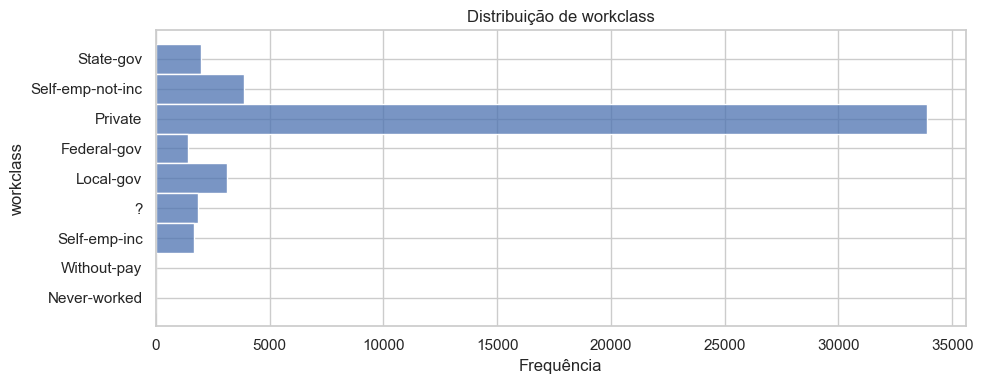

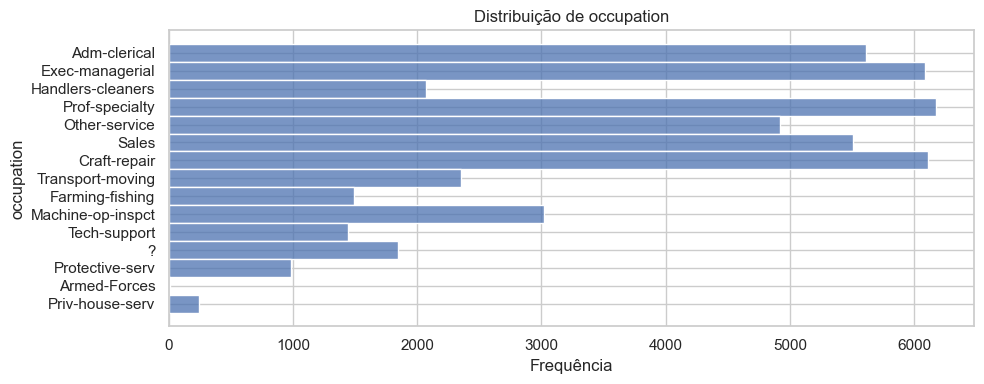

In [80]:
# Distribuição (histograma) de workclass
plt.figure(figsize=(10, 4))
sns.histplot(data=df, y='workclass')
plt.title('Distribuição de workclass')
plt.xlabel('Frequência')
plt.ylabel('workclass')
plt.tight_layout()
plt.show()

# Distribuição (histograma) de occupation
plt.figure(figsize=(10, 4))
sns.histplot(data=df, y='occupation')
plt.title('Distribuição de occupation')
plt.xlabel('Frequência')
plt.ylabel('occupation')
plt.tight_layout()
plt.show()

### Correlation Heatmap for All Features (Numerical and Encoded Categorical)

DataFrame shape after encoding: (48842, 97)


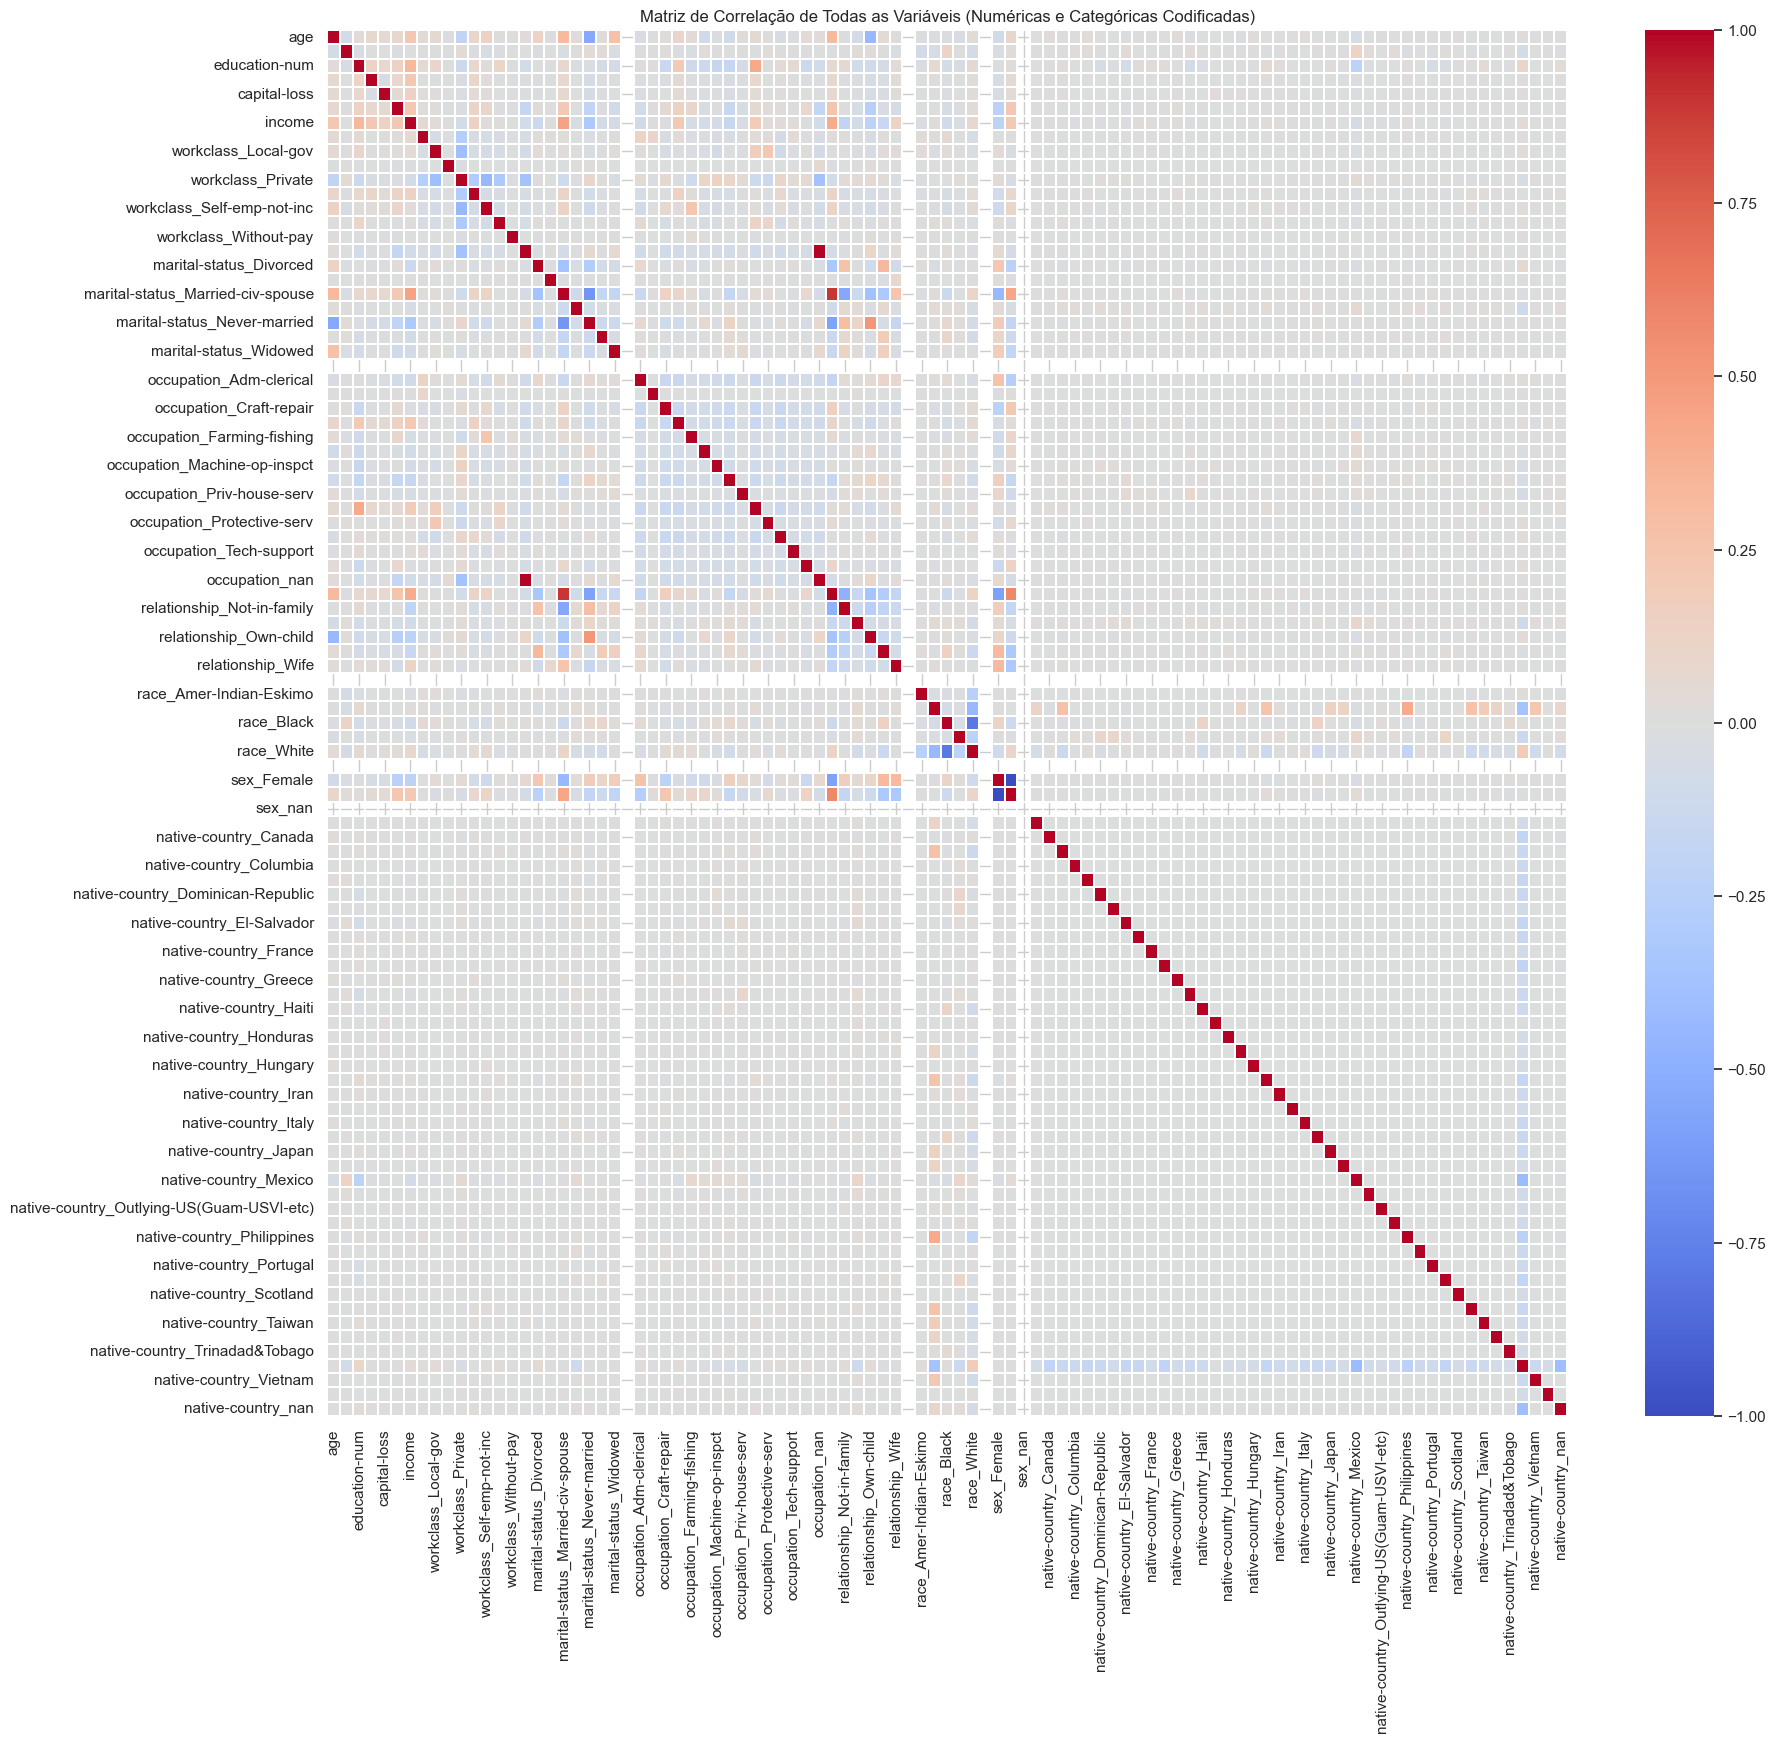

In [81]:

# Create a copy of the original DataFrame to avoid modifying it directly
df_processed = df.copy()

# 1. Clean and encode the 'income' target variable
df_processed['income'] = df_processed['income'].replace({'>50K.': '>50K', '<=50K.': '<=50K'})
df_processed['income'] = df_processed['income'].map({'<=50K': 0, '>50K': 1})

# 2. Replace '?' with NaN in specified columns
for col in ['workclass', 'occupation', 'native-country']:
    df_processed[col] = df_processed[col].replace('?', np.nan)

# 3. Drop the original 'education' column as 'education-num' already represents it numerically
df_processed = df_processed.drop(columns=['education'])

# 4. Identify nominal categorical columns for one-hot encoding
# Exclude 'income' as it's already encoded and numerical
nominal_cols = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

# 5. Apply one-hot encoding, treating NaN values as a separate category if present
df_encoded = pd.get_dummies(df_processed, columns=nominal_cols, dummy_na=True)

print(f"DataFrame shape after encoding: {df_encoded.shape}")

# Calculate the correlation matrix
correlation_matrix_all = df_encoded.corr()

# Create the heatmap
plt.figure(figsize=(20, 18)) # Adjust figure size for a larger heatmap
sns.heatmap(correlation_matrix_all, annot=False, cmap='coolwarm', fmt='.2f', linewidths=.1)
plt.title('Matriz de Correlação de Todas as Variáveis (Numéricas e Categóricas Codificadas)')
plt.show()

In [82]:
print("\n--- TOP PARES DE MAIOR CORRELAÇÃO (MULTICOLINEARIDADE) ---")

# 1. Isola apenas o triângulo superior da matriz
# Isso evita pares duplicados (ex: A com B e B com A) e ignora a correlação da variável com ela mesma (1.0)
matriz_triangular = correlation_matrix_all.where(
    np.triu(np.ones(correlation_matrix_all.shape), k=1).astype(bool)
)

# 2. "Desempilha" a matriz para transformar o cruzamento de colunas em uma lista de linhas
pares_correlacao = matriz_triangular.unstack().dropna()

# 3. Ordena pela FORÇA ABSOLUTA da correlação
# O 'key=abs' garante que tanto as correlações -0.9 quanto as +0.9 fiquem no topo da lista
pares_ordenados = pares_correlacao.sort_values(key=abs, ascending=False)

# 4. Define um limiar de corte para focar apenas no que é relevante (ajuste se necessário)
limiar_corte = 0.4
correlacoes_fortes = pares_ordenados[abs(pares_ordenados) > limiar_corte]

# 5. Formata e exibe o resultado como uma tabela clara
df_top_correlacoes = correlacoes_fortes.reset_index()
df_top_correlacoes.columns = ['Feature 1', 'Feature 2', 'Correlação']

# Exibe as 25 relações mais significativas
display(df_top_correlacoes.head(25))

print("Nota Técnica: Este ranking exibe os pares de features que possuem forte relação linear entre si.")
print("Atenção especial para pares preditores (Feature 1 e 2 sem ser o 'income') com alta correlação,")
print("pois isso indica multicolinearidade, o que pode enviesar o modelo de Machine Learning.")


--- TOP PARES DE MAIOR CORRELAÇÃO (MULTICOLINEARIDADE) ---


,Feature 1,Feature 2,Correlação
0,sex_Male,sex_Female,-1.000000
1,occupation_nan,workclass_nan,0.998110
2,relationship_Husband,marital-status_Married-civ-spouse,0.893676
3,race_White,race_Black,-0.791096
4,marital-status_Never-married,marital-status_Married-civ-spouse,-0.645362
5,sex_Male,relationship_Husband,0.579310
6,sex_Female,relationship_Husband,-0.579310
7,relationship_Husband,marital-status_Never-married,-0.577393
8,relationship_Not-in-family,marital-status_Married-civ-spouse,-0.539571
9,marital-status_Never-married,age,-0.538250


Nota Técnica: Este ranking exibe os pares de features que possuem forte relação linear entre si.
Atenção especial para pares preditores (Feature 1 e 2 sem ser o 'income') com alta correlação,
pois isso indica multicolinearidade, o que pode enviesar o modelo de Machine Learning.


## Limpeza dos dados


In [83]:
linhas, colunas = df.shape
print(f"Instâncias (linhas): {linhas} | colunas: {colunas}")

Instâncias (linhas): 48842 | colunas: 15


In [84]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [85]:
# =================================================================
# BLOCO: PADRONIZAÇÃO DA VARIÁVEL ALVO (TARGET)
# =================================================================

print("--- TRATAMENTO DA VARIÁVEL ALVO (INCOME) ---\n")

print("1. Contagem de classes ANTES da limpeza:")
print(df['income'].value_counts())

# A transformação:
# 1. Garante que é texto (str)
# 2. Substitui o ponto final por nada (remove)
# 3. Remove espaços em branco sobrando no início ou fim (strip)
df['income'] = df['income'].astype(str).str.replace('.', '', regex=False).str.strip()

print("\n" + "-" * 40 + "\n")

print("2. Contagem de classes APÓS a limpeza:")
print(df['income'].value_counts())



--- TRATAMENTO DA VARIÁVEL ALVO (INCOME) ---

1. Contagem de classes ANTES da limpeza:
income
<=50K    37155
>50K     11687
Name: count, dtype: int64

----------------------------------------

2. Contagem de classes APÓS a limpeza:
income
<=50K    37155
>50K     11687
Name: count, dtype: int64


In [86]:
print("--- Existem outliers e missing values ---")

# Calcula o número de instâncias com missing values
num_instances_with_missing = df.isnull().any(axis=1).sum()
print(f"Número de instâncias com missing values em qualquer posição: {num_instances_with_missing}")

# Missing values por coluna
missing_por_coluna = df.isnull().sum().sort_values(ascending=False)
print("Missing values por coluna:")
print(missing_por_coluna)


--- Existem outliers e missing values ---
Número de instâncias com missing values em qualquer posição: 1221
Missing values por coluna:
occupation        966
workclass         963
native-country    274
fnlwgt              0
education           0
education-num       0
age                 0
marital-status      0
relationship        0
sex                 0
race                0
capital-gain        0
capital-loss        0
hours-per-week      0
income              0
dtype: int64


In [87]:
# Remoção de linhas com missing values
before = len(df)
df = df.dropna()
after = len(df)
print(f"Linhas removidas por missing values: {before - after}")
print(f"Linhas restantes: {after}")


Linhas removidas por missing values: 1221
Linhas restantes: 47621


In [88]:
# Verificação de linhas duplicadas (idênticas)
num_dups = df.duplicated().sum()
print(f"Número de linhas duplicadas: {num_dups}")


Número de linhas duplicadas: 48


In [89]:
# Remoção de linhas duplicadas
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f"Linhas removidas por duplicidade: {before - after}")
print(f"Linhas restantes: {after}")


Linhas removidas por duplicidade: 48
Linhas restantes: 47573


In [90]:
# Remoção de inconsistências (label noise)
before = len(df)

# Lógica: Mantém apenas as linhas onde a combinação de features aponta para um único alvo
features_preditoras = list(df.columns.drop('income'))
contagem_rotulos = df.groupby(features_preditoras)['income'].transform('nunique')
df = df[contagem_rotulos == 1]

after = len(df)
print(f"Linhas removidas por inconsistência: {before - after}")
print(f"Linhas restantes: {after}")

Linhas removidas por inconsistência: 10
Linhas restantes: 47563


In [91]:
# resumo antes de feature engineering
linhas, colunas = df.shape
print(f"Instâncias (linhas): {linhas} | colunas: {colunas}\n")

# Contagem de valores únicos (cardinalidade) de cada feature
print("--- Quantidade de valores únicos por feature ---")
print(df.nunique())

# Exibe as 5 primeiras linhas (usar 'display' deixa a tabela mais bonita no Colab)
display(df.head())

Instâncias (linhas): 47563 | colunas: 15

--- Quantidade de valores únicos por feature ---
age                  74
workclass             9
fnlwgt            27946
education            16
education-num        16
marital-status        7
occupation           15
relationship          6
race                  5
sex                   2
capital-gain        122
capital-loss         98
hours-per-week       96
native-country       42
income                2
dtype: int64


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## Feature Engineering


In [92]:

# Re-fetch dataset and initial df (from cell 7LxHUIwksjfG and L6jYCjFU0gMb)
adult = fetch_ucirepo(id=2)
X_initial_fetch = adult.data.features
y_initial_fetch = adult.data.targets
df = pd.concat([X_initial_fetch, y_initial_fetch], axis=1)


In [93]:
# Agrupar paises: manter apenas os 3 mais frequentes e o resto em 'Outros' (inclui desconhecidos)
if 'native-country' in df.columns:
    total_before = len(df)
    top3 = df['native-country'].value_counts().head(3).index
    df['native-country'] = df['native-country'].where(df['native-country'].isin(top3), 'Outros')
    total_after = len(df)
    print(f"Linhas antes do agrupamento de pais: {total_before}")
    print(f"Linhas depois do agrupamento de pais: {total_after}")
    print('Top 3 paises:', list(top3))
    print(df['native-country'].value_counts())


Linhas antes do agrupamento de pais: 48842
Linhas depois do agrupamento de pais: 48842
Top 3 paises: ['United-States', 'Mexico', '?']
native-country
United-States    43832
Outros            3476
Mexico             951
?                  583
Name: count, dtype: int64


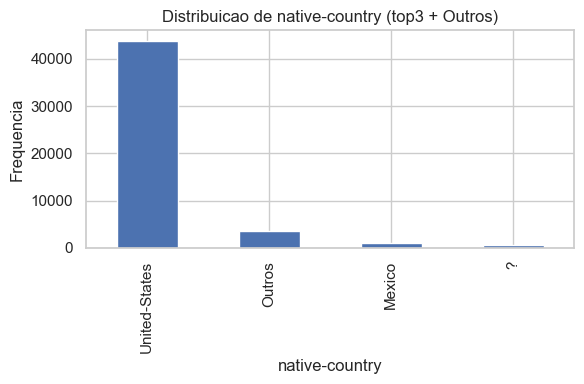

In [94]:
# Histograma (barra) de native-country apos agrupamento
if 'native-country' in df.columns:
    counts = df['native-country'].value_counts()
    ax = counts.plot(kind='bar', figsize=(6, 4))
    ax.set_title('Distribuicao de native-country (top3 + Outros)')
    ax.set_xlabel('native-country')
    ax.set_ylabel('Frequencia')
    plt.tight_layout()
    plt.show()


**Significado de algumas categorias da coluna `education`**

- `Assoc-acdm`: curso de *Associate* de natureza acadêmica (equivalente a um tecnólogo/curso superior curto, tipicamente 2 anos).
- `Assoc-voc`: curso de *Associate* de natureza vocacional/técnica (formação mais voltada ao mercado de trabalho).
- `10th`: 10º ano do ensino médio (high school) nos EUA.
- `11th`: 11º ano do ensino médio (high school) nos EUA.
- `12th`: 12º ano do ensino médio (high school) nos EUA, geralmente o último ano antes da graduação.


In [95]:

# Agrupamento de níveis de educação
edu_map = {
    'Preschool': 'dropout',
    '1st-4th': 'dropout',
    '5th-6th': 'dropout',
    '7th-8th': 'dropout',
    '9th': 'dropout',
    '10th': 'dropout',
    '11th': 'dropout',
    '12th': 'dropout',
    'HS-Grad': 'HighGrad',
    'HS-grad': 'HighGrad',
    'Some-college': 'CommunityCollege',
    'Assoc-acdm': 'CommunityCollege',
    'Assoc-voc': 'CommunityCollege',
    'Bachelors': 'Bachelors',
    'Masters': 'Masters',
    'Prof-school': 'Masters',
    'Doctorate': 'Doctorate',
}
df['education'] = df['education'].replace(edu_map)

# Média de education-num por categoria após o agrupamento
edu_mean = (
    df[['education', 'education-num']]
        .groupby(['education'], as_index=False)
        .mean()
        .sort_values(by='education-num', ascending=True)
)

display(edu_mean)

# OrdinalEncoder em education com ordem baseada em education-num
edu_order = edu_mean['education'].tolist()
edu_encoder = OrdinalEncoder(categories=[edu_order])
df['education'] = edu_encoder.fit_transform(df[['education']]).astype(int)


,education,education-num
5,dropout,5.614544
3,HighGrad,9.000000
1,CommunityCollege,10.361967
0,Bachelors,13.000000
4,Masters,14.238900
2,Doctorate,16.000000


In [96]:
# drop education-num
df = df.drop(columns=['education-num'])

In [97]:
# Drop de fnlwgt
df = df.drop(columns=['fnlwgt'])
print('fnlwgt presente:', 'fnlwgt' in df.columns)


fnlwgt presente: False


In [98]:
# Label encoding para sex
df['sex'] = pd.Categorical(df['sex']).codes
print('sex codificado (exemplo):')
print(df['sex'].value_counts().sort_index())


sex codificado (exemplo):
sex
0    16192
1    32650
Name: count, dtype: int64


In [99]:
# Discretização de age em faixas (0-18 fixo, demais por quantis)
age = df['age']
mask_adult = age > 18

# Quantis para distribuir uniformemente as idades adultas
n_bins = 8
age_bin = pd.Series(index=df.index, dtype='object')
age_bin.loc[mask_adult] = pd.qcut(age[mask_adult], q=n_bins, duplicates='drop').astype(str)
age_bin.loc[~mask_adult] = '0-18'
df['age_bin'] = age_bin.astype('category')
print(df['age_bin'].value_counts().sort_index())

# Remoção de age após binarização
if 'age' in df.columns:
    df = df.drop(columns=['age'])
print('age presente:', 'age' in df.columns)


age_bin
(18.999, 24.0]    6975
(24.0, 29.0]      6083
(29.0, 33.0]      5191
(33.0, 38.0]      6532
(38.0, 43.0]      5897
(43.0, 48.0]      5186
(48.0, 56.0]      5837
(56.0, 90.0]      5684
0-18              1457
Name: count, dtype: int64
age presente: False


In [100]:
# Agrupamento de marital-status
marital_map = {
    'Never-married': 'NotMarried',
    'Married-AF-spouse': 'Married',
    'Married-civ-spouse': 'Married',
    'Married-spouse-absent': 'NotMarried',
    'Separated': 'Separated',
    'Divorced': 'Separated',
    'Widowed': 'Widowed',
}
df['marital-status'] = df['marital-status'].replace(marital_map)


**Categorias de marital-status**

- `Married-AF-spouse`: casado com cônjuge nas Forças Armadas dos EUA (AF = Armed Forces).
- `Married-civ-spouse`: casado com cônjuge civil (não militar).
- `Married-spouse-absent`: casado(a), mas o cônjuge está ausente (por separação de fato, trabalho, etc.).


In [101]:
# Discretização estatisticamente uniforme de hours-per-week (quantis)
# 5 grupos é um número razoável e mantém interpretabilidade
n_bins = 5
df['hours-per-week-bin'] = pd.qcut(df['hours-per-week'], q=n_bins, duplicates='drop')
print('Bins de hours-per-week:', df['hours-per-week-bin'].cat.categories)

# Remoção de hours-per-week após binarização
if 'hours-per-week' in df.columns:
    df = df.drop(columns=['hours-per-week'])
print('hours-per-week presente:', 'hours-per-week' in df.columns)


Bins de hours-per-week: IntervalIndex([(0.999, 35.0], (35.0, 40.0], (40.0, 48.0], (48.0, 99.0]], dtype='interval[float64, right]')
hours-per-week presente: False


In [102]:
# Snapshot do dataframe categórico antes do one-hot
df_cat = df.copy()


In [103]:
# Feature: capital-balance (capital-gain - capital-loss)
if 'capital-balance' not in df.columns:
    if 'capital-gain' in df.columns and 'capital-loss' in df.columns:
        df['capital-balance'] = df['capital-gain'] - df['capital-loss']
    else:
        raise KeyError('capital-gain/capital-loss ausentes para criar capital-balance')

# Remoção de capital-gain e capital-loss após criar capital-balance
cols_to_drop = [c for c in ['capital-gain', 'capital-loss'] if c in df.columns]
if cols_to_drop:
    df = df.drop(columns=cols_to_drop)
    print('Colunas removidas:', cols_to_drop)


Colunas removidas: ['capital-gain', 'capital-loss']


In [104]:
# resumo antes do one-hot encoding
linhas, colunas = df.shape
print(f"Instâncias (linhas): {linhas} | colunas: {colunas}\n")

# Contagem de valores únicos (cardinalidade) de cada feature
print("--- Quantidade de valores únicos por feature ---")
print(df.nunique())

# Exibe as 5 primeiras linhas (usar 'display' deixa a tabela mais bonita no Colab)
display(df.head())

Instâncias (linhas): 48842 | colunas: 12

--- Quantidade de valores únicos por feature ---
workclass               9
education               6
marital-status          4
occupation             15
relationship            6
race                    5
sex                     2
native-country          4
income                  4
age_bin                 9
hours-per-week-bin      4
capital-balance       221
dtype: int64


,workclass,education,marital-status,occupation,relationship,race,sex,native-country,income,age_bin,hours-per-week-bin,capital-balance
0,State-gov,3,NotMarried,Adm-clerical,Not-in-family,White,1,United-States,<=50K,"(38.0, 43.0]","(35.0, 40.0]",2174
1,Self-emp-not-inc,3,Married,Exec-managerial,Husband,White,1,United-States,<=50K,"(48.0, 56.0]","(0.999, 35.0]",0
2,Private,1,Separated,Handlers-cleaners,Not-in-family,White,1,United-States,<=50K,"(33.0, 38.0]","(35.0, 40.0]",0
3,Private,0,Married,Handlers-cleaners,Husband,Black,1,United-States,<=50K,"(48.0, 56.0]","(35.0, 40.0]",0
4,Private,3,Married,Prof-specialty,Wife,Black,0,Outros,<=50K,"(24.0, 29.0]","(35.0, 40.0]",0


### Comparativos de Distribuição (before vs after One-Hot Encoding)

--- GERANDO PAINEL COMPARATIVO ---


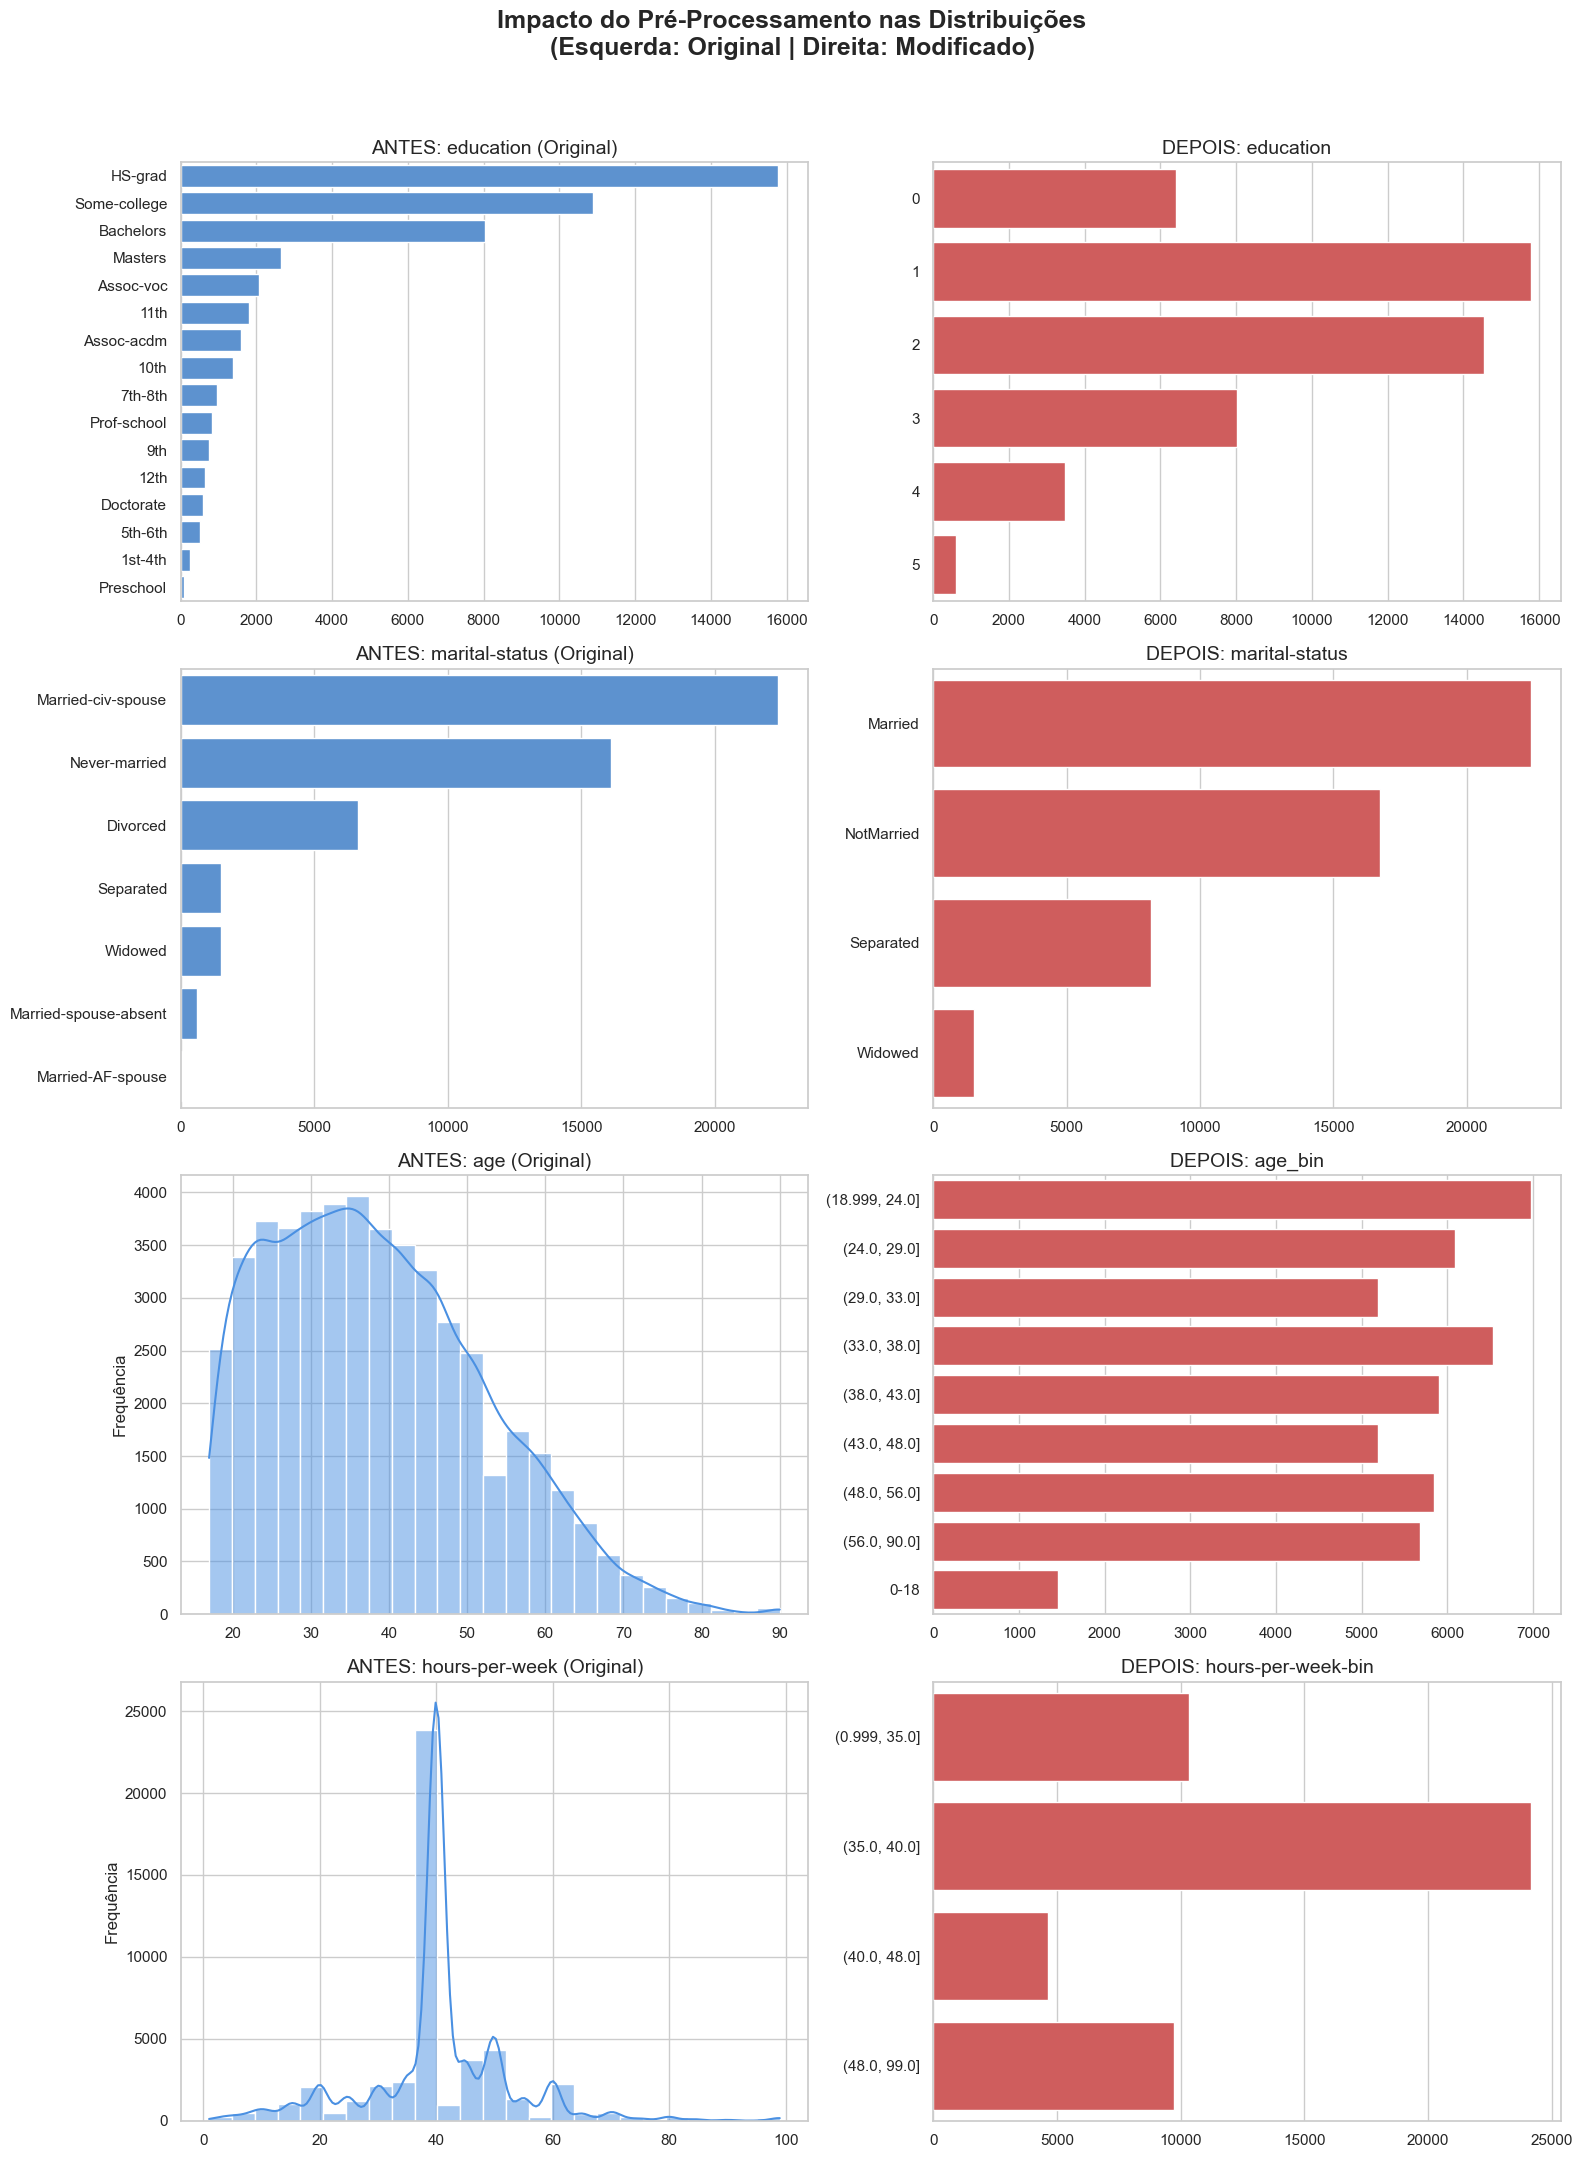

In [105]:
# =================================================================
# BLOCO: COMPARATIVO DE DISTRIBUIÇÕES (MAPEAMENTO DE NOMES)
# =================================================================

print("--- GERANDO PAINEL COMPARATIVO ---")

df_antes = df_original.copy()
df_antes = df_antes.replace(r'^\s*\?\s*$', np.nan, regex=True)

df_depois = df.copy()

# Lista das features originais para montar o eixo da esquerda
features_originais = ['education', 'marital-status', 'age', 'hours-per-week']

# Dicionário tradutor: 'Nome Antigo' : 'Nome Novo no df_depois'
mapa_nomes = {
    'age': 'age_bin',
    'hours-per-week': 'hours-per-week-bin',
    'education': 'education',
    'marital-status': 'marital-status'
}

# Configuração do Painel (4 linhas, 2 colunas)
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 22))
fig.suptitle('Impacto do Pré-Processamento nas Distribuições\n(Esquerda: Original | Direita: Modificado)',
             fontsize=18, fontweight='bold', y=0.98)

for i, feature_original in enumerate(features_originais):
    feature_nova = mapa_nomes[feature_original]

    # ==========================================
    # LADO ESQUERDO: ANTES (Base Original)
    # ==========================================
    ax_antes = axes[i, 0]
    if df_antes[feature_original].dtype in ['int64', 'float64']:
        sns.histplot(data=df_antes, x=feature_original, kde=True, ax=ax_antes, color='#4A90E2', bins=25)
        ax_antes.set_ylabel('Frequência')
    else:
        sns.countplot(data=df_antes, y=feature_original, ax=ax_antes, color='#4A90E2',
                      order=df_antes[feature_original].value_counts().index)
        ax_antes.set_ylabel('')

    ax_antes.set_title(f'ANTES: {feature_original} (Original)', fontsize=14)
    ax_antes.set_xlabel('')

    # ==========================================
    # LADO DIREITO: DEPOIS (Transformado)
    # ==========================================
    ax_depois = axes[i, 1]

    if feature_nova in df_depois.columns:
        # Se for contínua (numérica com muitos valores)
        if df_depois[feature_nova].dtype in ['int64', 'float64'] and df_depois[feature_nova].nunique() > 16:
            sns.histplot(data=df_depois, x=feature_nova, kde=True, ax=ax_depois, color='#E24A4A', bins=25)
            ax_depois.set_ylabel('')

        # Se for texto, categoria, ordinal ou discretizada (bins)
        else:
            try:
                # Tenta ordenar naturalmente (perfeito para bins numéricos ou categorias ordenáveis)
                ordem_exibicao = sorted(df_depois[feature_nova].dropna().unique())
            except TypeError:
                # Se falhar (ex: string vs float), ordena por quem tem mais volume
                ordem_exibicao = df_depois[feature_nova].value_counts().index

            sns.countplot(data=df_depois, y=feature_nova, ax=ax_depois, color='#E24A4A', order=ordem_exibicao)
            ax_depois.set_ylabel('')

        ax_depois.set_title(f'DEPOIS: {feature_nova}', fontsize=14)
        ax_depois.set_xlabel('')

    # Se a feature tiver sumido por algum outro erro
    else:
        mensagem_erro = f"Feature '{feature_nova}' não encontrada no df atual."
        ax_depois.text(0.5, 0.5, mensagem_erro, ha='center', va='center', fontsize=12, color='red', fontweight='bold')
        ax_depois.set_title(f'DEPOIS: {feature_nova} (Ausente)', fontsize=14)
        ax_depois.axis('off')

# Ajusta o layout
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [106]:
# =================================================================
# BLOCO: ANÁLISE DA PROPORÇÃO DAS CLASSES (NO DATAFRAME ATUAL)
# =================================================================

# 1. Limpeza e Normalização da coluna 'income' dentro do df
# Remove pontos finais e espaços extras que podem causar categorias duplicadas
df['income'] = df['income'].astype(str).str.replace('.', '', regex=False).str.strip()

# 2. Contagem e Porcentagem baseada no df processado
contagem_classes = df['income'].value_counts()
porcentagem_classes = df['income'].value_counts(normalize=True) * 100

# 3. Criação do DataFrame de Resumo
resumo_classes = pd.DataFrame({
    'Quantidade': contagem_classes,
    'Proporção (%)': porcentagem_classes.round(2) # Arredondado para facilitar a leitura
})

print("--- DISTRIBUIÇÃO UNIFICADA DAS CLASSES (PÓS-LIMPEZA) ---")
print(resumo_classes)
print(f"\nTotal de instâncias analisadas: {len(df)}")


--- DISTRIBUIÇÃO UNIFICADA DAS CLASSES (PÓS-LIMPEZA) ---
        Quantidade  Proporção (%)
income                           
<=50K        37155          76.07
>50K         11687          23.93

Total de instâncias analisadas: 48842


### One Hot ENCODING

In [107]:
# One-Hot Encoding para marital-status, relationship, race, native-country, occupation, workclass, age_bin e hours-per-week-bin
ohe_cols = ['marital-status', 'relationship', 'race', 'native-country', 'occupation', 'workclass', 'age_bin', 'hours-per-week-bin']
df = pd.get_dummies(df, columns=ohe_cols, prefix=ohe_cols, drop_first=False)
print('One-hot aplicado em:', ohe_cols)
print('Colunas atuais:', len(df.columns))


One-hot aplicado em: ['marital-status', 'relationship', 'race', 'native-country', 'occupation', 'workclass', 'age_bin', 'hours-per-week-bin']
Colunas atuais: 60


In [108]:
# Preparação da target
target_col = y.columns[0]
df[target_col] = df[target_col].astype(str).str.strip().str.replace('.', '', regex=False)
vals = sorted(df[target_col].dropna().unique())
print('Valores da target:', vals)

if '>50K' in vals:
    target_positive = '>50K'
elif '1' in vals:
    target_positive = '1'
else:
    target_positive = vals[-1]

df['_target_bin'] = (df[target_col] == target_positive).astype(int)
df = df.drop(columns=[target_col])

print('Target positiva:', target_positive)
print(df['_target_bin'].value_counts())


Valores da target: ['<=50K', '>50K']
Target positiva: >50K
_target_bin
0    37155
1    11687
Name: count, dtype: int64


In [109]:
# Amostra do dataframe após o feature engineering
# Garante a target binária como última coluna
cols = [c for c in df.columns if c != '_target_bin'] + ['_target_bin']
df = df[cols]

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 0)

df.head()


,education,sex,capital-balance,marital-status_Married,marital-status_NotMarried,marital-status_Separated,marital-status_Widowed,relationship_Husband,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White,native-country_?,native-country_Mexico,native-country_Outros,native-country_United-States,occupation_?,occupation_Adm-clerical,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,workclass_?,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,"age_bin_(18.999, 24.0]","age_bin_(24.0, 29.0]","age_bin_(29.0, 33.0]","age_bin_(33.0, 38.0]","age_bin_(38.0, 43.0]","age_bin_(43.0, 48.0]","age_bin_(48.0, 56.0]","age_bin_(56.0, 90.0]",age_bin_0-18,"hours-per-week-bin_(0.999, 35.0]","hours-per-week-bin_(35.0, 40.0]","hours-per-week-bin_(40.0, 48.0]","hours-per-week-bin_(48.0, 99.0]",_target_bin
0,3,1,2174,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,0
1,3,1,0,True,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,0
2,1,1,0,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,0
3,0,1,0,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,0
4,3,0,0,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,0


In [110]:
# resumo após do one-hot encoding
linhas, colunas = df.shape
print(f"Instâncias (linhas): {linhas} | colunas: {colunas}\n")

# Contagem de valores únicos (cardinalidade) de cada feature
print("--- Quantidade de valores únicos por feature ---")
print(df.nunique())

# Exibe as 5 primeiras linhas (usar 'display' deixa a tabela mais bonita no Colab)
display(df.head())

Instâncias (linhas): 48842 | colunas: 60

--- Quantidade de valores únicos por feature ---
education                             6
sex                                   2
capital-balance                     221
marital-status_Married                2
marital-status_NotMarried             2
marital-status_Separated              2
marital-status_Widowed                2
relationship_Husband                  2
relationship_Not-in-family            2
relationship_Other-relative           2
relationship_Own-child                2
relationship_Unmarried                2
relationship_Wife                     2
race_Amer-Indian-Eskimo               2
race_Asian-Pac-Islander               2
race_Black                            2
race_Other                            2
race_White                            2
native-country_?                      2
native-country_Mexico                 2
native-country_Outros                 2
native-country_United-States          2
occupation_?                 

,education,sex,capital-balance,marital-status_Married,marital-status_NotMarried,marital-status_Separated,marital-status_Widowed,relationship_Husband,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White,native-country_?,native-country_Mexico,native-country_Outros,native-country_United-States,occupation_?,occupation_Adm-clerical,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,workclass_?,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,"age_bin_(18.999, 24.0]","age_bin_(24.0, 29.0]","age_bin_(29.0, 33.0]","age_bin_(33.0, 38.0]","age_bin_(38.0, 43.0]","age_bin_(43.0, 48.0]","age_bin_(48.0, 56.0]","age_bin_(56.0, 90.0]",age_bin_0-18,"hours-per-week-bin_(0.999, 35.0]","hours-per-week-bin_(35.0, 40.0]","hours-per-week-bin_(40.0, 48.0]","hours-per-week-bin_(48.0, 99.0]",_target_bin
0,3,1,2174,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,0
1,3,1,0,True,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,0
2,1,1,0,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,0
3,0,1,0,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,0
4,3,0,0,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,0


## Reparos

Checklist de colunas esperadas antes de rodar EDA/FE.


In [111]:
# Diagnóstico rápido de colunas esperadas
expected_cols = [
    "hours-per-week-bin", "marital-status", "relationship", "race", "sex",
    "workclass", "occupation", "native-country", "_target_bin"
]
missing = [c for c in expected_cols if c not in df.columns]
print('Colunas ausentes:', missing)

# Se alguma estiver ausente, rode a célula correspondente antes


Colunas ausentes: ['hours-per-week-bin', 'marital-status', 'relationship', 'race', 'workclass', 'occupation', 'native-country']


## EDA (pós-Feature Engineering)


In [112]:
# Helpers para correlação e distribuição por classe

sns.set_theme(style='whitegrid')

def cramers_v(col_a, col_b):
    ct = pd.crosstab(col_a, col_b)
    chi2, p, _, _ = chi2_contingency(ct)
    n = ct.to_numpy().sum()
    phi2 = chi2 / n
    r, k = ct.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    v = np.sqrt(phi2corr / max(1, min((kcorr - 1), (rcorr - 1))))
    return v, p, ct

def hist_by_class_num(col, bins=30, cap_upper=None, data=None):
    data = df if data is None else data
    data = data[[col, "_target_bin"]].copy()
    if cap_upper is not None:
        data[col] = data[col].clip(upper=cap_upper)

    plt.figure(figsize=(8, 4))
    sns.histplot(data=data, x=col, hue="_target_bin", bins=bins, kde=False, stat="count", common_norm=False)
    if cap_upper is not None:
        plt.axvline(cap_upper, color="gray", linestyle="--", linewidth=1)
    plt.title(f"Distribuição de {col} por classe da target")
    plt.xlabel(col)
    plt.ylabel("Frequência")
    plt.tight_layout()
    plt.show()

def plot_dist_by_class(col, title, bins=30, cap_upper=None, data=None):
    data = df if data is None else data
    if "_target_bin" not in data.columns:
        data = data.copy()
        data["_target_bin"] = df["_target_bin"].values
    data = data[[col, "_target_bin"]].copy()
    if cap_upper is not None:
        data[col] = data[col].clip(upper=cap_upper)

    plt.figure(figsize=(8, 4))
    if pd.api.types.is_numeric_dtype(data[col]):
        sns.histplot(data=data, x=col, hue='_target_bin', bins=bins, kde=False, stat='count', common_norm=False)
        if cap_upper is not None:
            plt.axvline(cap_upper, color='gray', linestyle='--', linewidth=1)
            plt.title(f"{title} (>= {cap_upper} agrupado em {cap_upper}+")
            ax = plt.gca()
            ticks = sorted(set(list(ax.get_xticks()) + [cap_upper]))
            labels = [str(int(t)) if t != cap_upper else f"{int(cap_upper)}+" for t in ticks]
            ax.set_xticks(ticks)
            ax.set_xticklabels(labels)
        else:
            plt.title(title)
    else:
        sns.countplot(data=data, x=col, hue='_target_bin')
        plt.title(title)
        plt.xticks(rotation=45, ha='right')

    plt.xlabel(col)
    plt.ylabel('Frequência')
    plt.tight_layout()
    plt.show()


In [113]:
# Associação entre marital-status e relationship (Cramér's V)
v, p, ct = cramers_v(df_cat['marital-status'], df_cat['relationship'])
print(f"Cramér's V: {v:.3f} | p-value: {p:.4g}")
print('Contingência (linhas x colunas):', ct.shape)


Cramér's V: 0.624 | p-value: 0
Contingência (linhas x colunas): (4, 6)


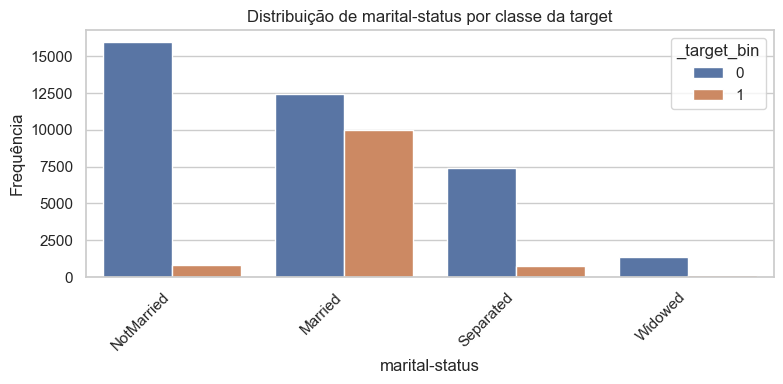

In [114]:
# Impacto de marital-status na target (distribuição por classe)
plot_dist_by_class('marital-status', 'Distribuição de marital-status por classe da target', data=df_cat)


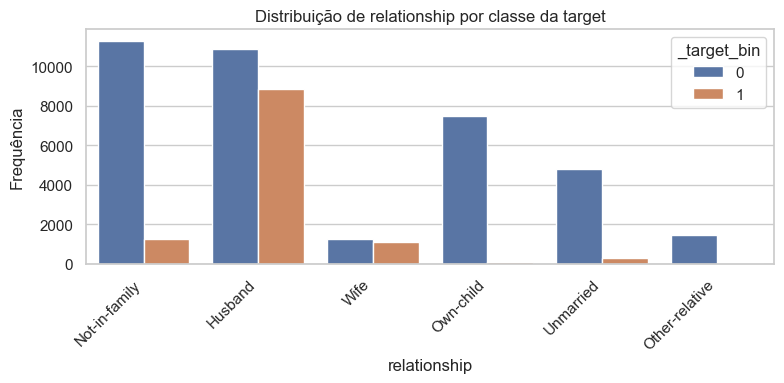

In [115]:
# Impacto de relationship na target (distribuição por classe)
plot_dist_by_class('relationship', 'Distribuição de relationship por classe da target', data=df_cat)


Cramér's V: 0.099 | p-value: 4.284e-104


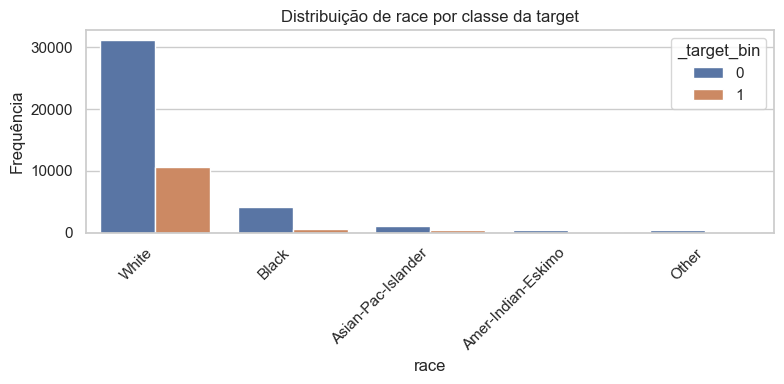

In [116]:
# Impacto de race na target (Cramér's V + distribuição por classe)
v, p, _ = cramers_v(df_cat['race'], df['_target_bin'])
print(f"Cramér's V: {v:.3f} | p-value: {p:.4g}")
plot_dist_by_class('race', 'Distribuição de race por classe da target', data=df_cat)


Cramér's V: 0.215 | p-value: 0


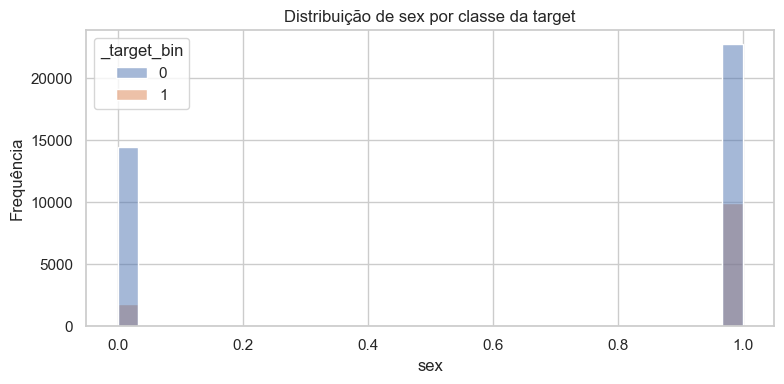

In [117]:
# Impacto de sex na target (Cramér's V + distribuição por classe)
v, p, _ = cramers_v(df_cat['sex'], df['_target_bin'])
print(f"Cramér's V: {v:.3f} | p-value: {p:.4g}")
plot_dist_by_class('sex', 'Distribuição de sex por classe da target', data=df_cat)


Matriz de correlação (Pearson) - numéricas:
                 education       sex  capital-balance  _target_bin
education         1.000000  0.014582         0.127481     0.344948
sex               0.014582  1.000000         0.044494     0.214628
capital-balance   0.127481  0.044494         1.000000     0.214356
_target_bin       0.344948  0.214628         0.214356     1.000000


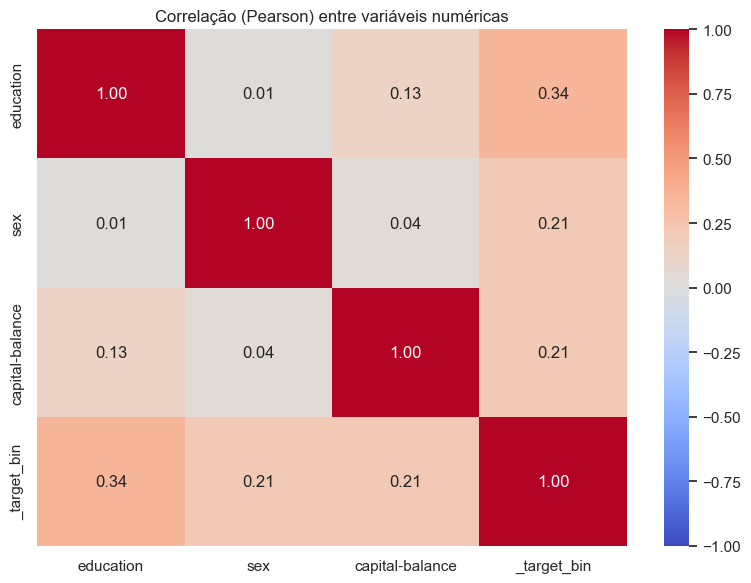

In [118]:
# Correlação entre variáveis numéricas (inclui target binária)
num_cols = df.select_dtypes(include=['number']).columns.tolist()
corr = df[num_cols].corr(method='pearson')
print('Matriz de correlação (Pearson) - numéricas:')
print(corr)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlação (Pearson) entre variáveis numéricas')
plt.tight_layout()
plt.show()


Cramér's V: 0.316 | p-value: 0


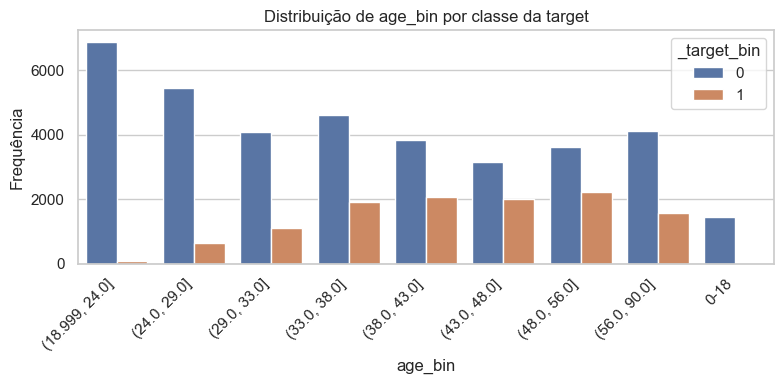

In [119]:
# Impacto de age_bin na target (Cramér's V + distribuição por classe)
v, p, _ = cramers_v(df_cat['age_bin'], df['_target_bin'])
print(f"Cramér's V: {v:.3f} | p-value: {p:.4g}")
plot_dist_by_class('age_bin', 'Distribuição de age_bin por classe da target', data=df_cat)


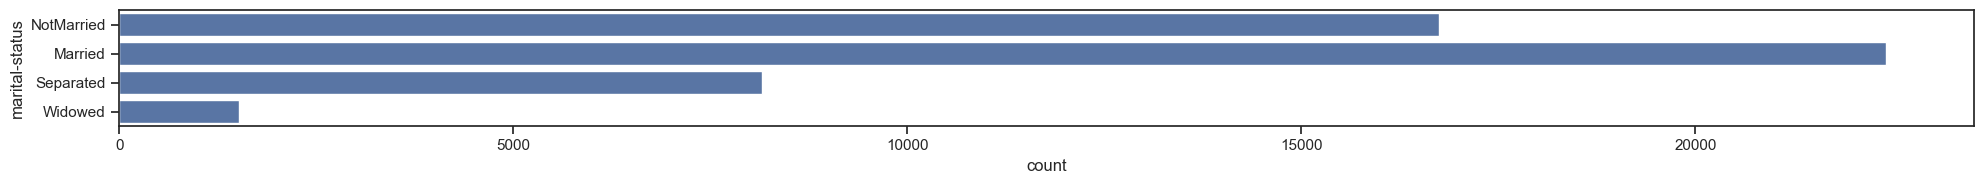

In [120]:
# Distribuição de marital-status
plt.figure(figsize=(20, 2))
sns.set_theme(style='ticks')
sns.countplot(y='marital-status', data=df_cat)
plt.tight_layout()
plt.show()


count    48842.000000
mean       991.565313
std       7475.549906
min      -4356.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: capital-balance, dtype: float64


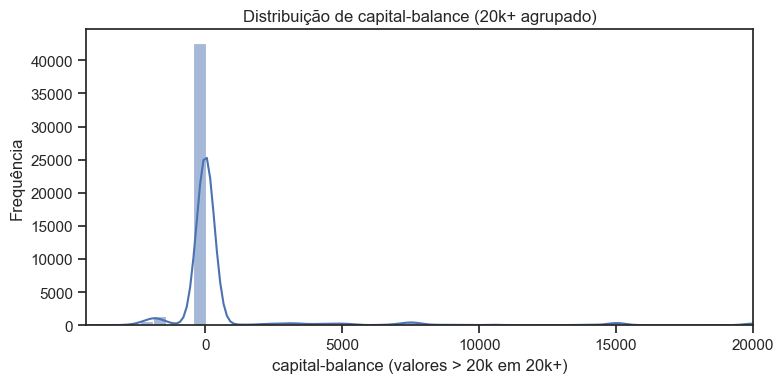

In [121]:
# Distribuição de capital-balance (com cap em 20k+)
print(df['capital-balance'].describe())
cb_clip = df['capital-balance'].clip(upper=20000)
plt.figure(figsize=(8, 4))
sns.histplot(cb_clip, bins=50, kde=True)
plt.title('Distribuição de capital-balance (20k+ agrupado)')
plt.xlabel('capital-balance (valores > 20k em 20k+)')
plt.ylabel('Frequência')
plt.xlim(cb_clip.min(), 20000)
plt.tight_layout()
plt.show()


Point-biserial: 0.214 | p-value: 0


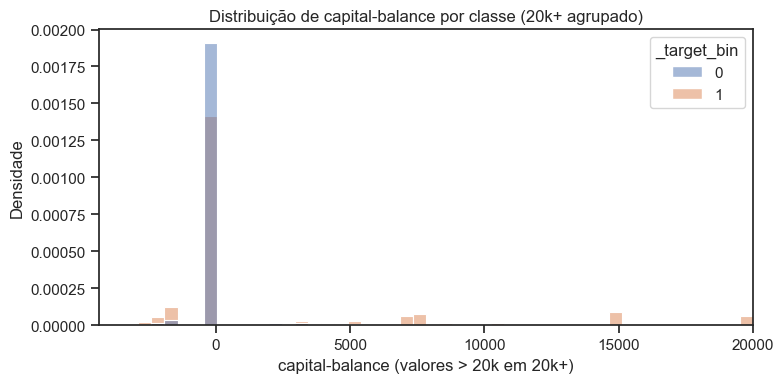

In [122]:
# Correlação de capital-balance com a target (point-biserial + distribuição por classe)
corr, p = pointbiserialr(df['_target_bin'], df['capital-balance'])
print(f"Point-biserial: {corr:.3f} | p-value: {p:.4g}")

cb_clip = df['capital-balance'].clip(upper=20000)
plt.figure(figsize=(8, 4))
sns.histplot(
    data=df.assign(capital_balance_clip=cb_clip),
    x='capital_balance_clip',
    hue='_target_bin',
    bins=50,
    kde=False,
    stat='density',
    common_norm=False,
    alpha=0.5,
)
plt.title('Distribuição de capital-balance por classe (20k+ agrupado)')
plt.xlabel('capital-balance (valores > 20k em 20k+)')
plt.ylabel('Densidade')
plt.xlim(cb_clip.min(), 20000)
plt.tight_layout()
plt.show()


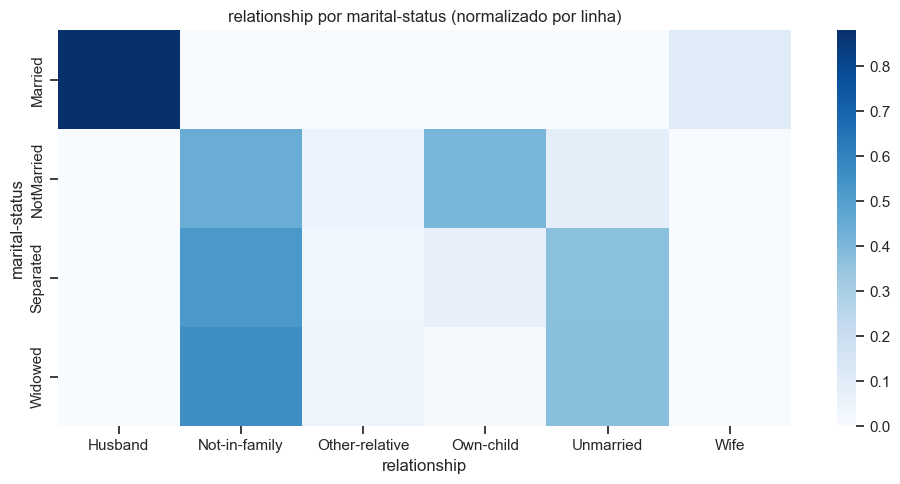

In [123]:
# Heatmap: relationship por marital-status (normalizado por linha)
ct = pd.crosstab(df_cat['marital-status'], df_cat['relationship'])
ct_norm = ct.div(ct.sum(axis=1), axis=0)
plt.figure(figsize=(10, 5))
sns.heatmap(ct_norm, cmap='Blues')
plt.title('relationship por marital-status (normalizado por linha)')
plt.xlabel('relationship')
plt.ylabel('marital-status')
plt.tight_layout()
plt.show()


In [124]:
df.head()

,education,sex,capital-balance,marital-status_Married,marital-status_NotMarried,marital-status_Separated,marital-status_Widowed,relationship_Husband,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White,native-country_?,native-country_Mexico,native-country_Outros,native-country_United-States,occupation_?,occupation_Adm-clerical,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,workclass_?,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,"age_bin_(18.999, 24.0]","age_bin_(24.0, 29.0]","age_bin_(29.0, 33.0]","age_bin_(33.0, 38.0]","age_bin_(38.0, 43.0]","age_bin_(43.0, 48.0]","age_bin_(48.0, 56.0]","age_bin_(56.0, 90.0]",age_bin_0-18,"hours-per-week-bin_(0.999, 35.0]","hours-per-week-bin_(35.0, 40.0]","hours-per-week-bin_(40.0, 48.0]","hours-per-week-bin_(48.0, 99.0]",_target_bin
0,3,1,2174,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,0
1,3,1,0,True,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,0
2,1,1,0,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,0
3,0,1,0,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,0
4,3,0,0,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,0


## Preparar Dados para Seleção de Características

Garantir que o DataFrame `df` esteja na sua forma final após o pré-processamento e feature engineering, com as colunas categóricas devidamente codificadas e o target binarizado '_target_bin' pronto para uso. Identificar as colunas de features e a coluna alvo.


In [125]:

# Re-fetch dataset and initial df (from cell 7LxHUIwksjfG and L6jYCjFU0gMb)
adult = fetch_ucirepo(id=2)
X_initial_fetch = adult.data.features
y_initial_fetch = adult.data.targets
df = pd.concat([X_initial_fetch, y_initial_fetch], axis=1)

# --- Start of Cleaning (from cell m5R_uhQIyTno onwards) ---
# Target standardization
df['income'] = df['income'].astype(str).str.replace('.', '', regex=False).str.strip()

# Replace '?' with NaN in relevant columns (from EDA analysis like HXz2qhZi4-Mi)
for col in ['workclass', 'occupation', 'native-country']:
    if col in df.columns and df[col].dtype == 'object':
        df[col] = df[col].replace('?', np.nan)

# Missing values removal (from AySKx8Eth-Vs)
df = df.dropna()

# Duplicate removal (from m2Pt_Fhlh-Vt)
df = df.drop_duplicates()

# Inconsistency removal (from w1itaZ2tsbT6)
features_preditoras_temp = list(df.columns.drop('income'))
contagem_rotulos = df.groupby(features_preditoras_temp)['income'].transform('nunique')
df = df[contagem_rotulos == 1]
# --- End of Cleaning ---

# --- Start of Feature Engineering (from Is1aASpuh-Vu onwards) ---
# Agrupamento de níveis de education
edu_map = {
    'Preschool': 'dropout', '1st-4th': 'dropout', '5th-6th': 'dropout',
    '7th-8th': 'dropout', '9th': 'dropout', '10th': 'dropout',
    '11th': 'dropout', '12th': 'dropout', 'HS-Grad': 'HighGrad',
    'HS-grad': 'HighGrad', 'Some-college': 'CommunityCollege',
    'Assoc-acdm': 'CommunityCollege', 'Assoc-voc': 'CommunityCollege',
    'Bachelors': 'Bachelors', 'Masters': 'Masters',
    'Prof-school': 'Masters', 'Doctorate': 'Doctorate',
}
df['education'] = df['education'].replace(edu_map)

# Média de education-num por categoria após o agrupamento (used to define order)
edu_mean = df[['education', 'education-num']].groupby(['education'], as_index=False).mean().sort_values(by='education-num', ascending=True)

# OrdinalEncoder em education com ordem baseada em education-num
edu_order = edu_mean['education'].tolist()
edu_encoder = OrdinalEncoder(categories=[edu_order])
df['education'] = edu_encoder.fit_transform(df[['education']]).astype(int)

# Drop education-num (from 6hWLh0fsh-Vu)
df = df.drop(columns=['education-num'])

# Drop de fnlwgt (from UjZDM_8Rh-Vu)
df = df.drop(columns=['fnlwgt'])

# Label encoding para sex (from ZFdtUhQoh-Vu)
df['sex'] = pd.Categorical(df['sex']).codes

# Discretização de age em faixas (from eedF2puNh-Vu)
age = df['age']
mask_adult = age > 18
n_bins = 8
age_bin = pd.Series(index=df.index, dtype='object')
age_bin.loc[mask_adult] = pd.qcut(age[mask_adult], q=n_bins, duplicates='drop').astype(str)
age_bin.loc[~mask_adult] = '0-18'
df['age_bin'] = age_bin.astype('category')
df = df.drop(columns=['age'])

# Agrupamento de marital-status (from _Ku8-xmbh-Vu)
marital_map = {
    'Never-married': 'NotMarried', 'Married-AF-spouse': 'Married',
    'Married-civ-spouse': 'Married', 'Married-spouse-absent': 'NotMarried',
    'Separated': 'Separated', 'Divorced': 'Separated', 'Widowed': 'Widowed',
}
df['marital-status'] = df['marital-status'].replace(marital_map)

# Discretização estatisticamente uniforme de hours-per-week (from FDc8uUiFh-Vu)
n_bins = 5
df['hours-per-week-bin'] = pd.qcut(df['hours-per-week'], q=n_bins, duplicates='drop')
df = df.drop(columns=['hours-per-week'])

# Feature: capital-balance (from rAIcfandh-Vu)
# Ensure capital-gain and capital-loss columns exist before calculating capital-balance
if 'capital-gain' in df.columns and 'capital-loss' in df.columns:
    df['capital-balance'] = df['capital-gain'] - df['capital-loss']
# Drop original capital-gain and capital-loss only if they exist and capital-balance was created
if 'capital-balance' in df.columns:
    df = df.drop(columns=['capital-gain', 'capital-loss'])
# --- End of Feature Engineering ---


# --- Start of One-Hot Encoding (from HCJqqgIxh-Vu onwards) ---
ohe_cols = ['marital-status', 'relationship', 'race', 'native-country', 'occupation', 'workclass', 'age_bin', 'hours-per-week-bin']
df = pd.get_dummies(df, columns=ohe_cols, prefix=ohe_cols, drop_first=False)

# Target binarization (from cRtzpWT7h-Vu)
target_col = 'income' # Original target name
df[target_col] = df[target_col].astype(str).str.strip().str.replace('.', '', regex=False)
vals = sorted(df[target_col].dropna().unique())
target_positive = '>50K' # Based on previous output
df['_target_bin'] = (df[target_col] == target_positive).astype(int)
df = df.drop(columns=[target_col])

# Column reordering (from BAc8a4Pah-Vu)
cols = [c for c in df.columns if c != '_target_bin'] + ['_target_bin']
df = df[cols]
# --- End of One-Hot Encoding and final df preparation ---

# --- Original code from cell 875a0451 starts here ---
print("### 1. Primeiras linhas do DataFrame 'df' (após feature engineering e encoding):\n")
display(df.head())

# 2. Criar X (features) e y (target)
X = df.drop(columns=['_target_bin'])
y = df['_target_bin']

print("\n### 3. Formato dos DataFrames X e y após a separação:\n")
print(f"Shape de X (features): {X.shape}")
print(f"Shape de y (target): {y.shape}")

### 1. Primeiras linhas do DataFrame 'df' (após feature engineering e encoding):



,education,sex,capital-balance,marital-status_Married,marital-status_NotMarried,marital-status_Separated,marital-status_Widowed,relationship_Husband,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White,native-country_?,native-country_Cambodia,native-country_Canada,native-country_China,native-country_Columbia,native-country_Cuba,native-country_Dominican-Republic,native-country_Ecuador,native-country_El-Salvador,native-country_England,native-country_France,native-country_Germany,native-country_Greece,native-country_Guatemala,native-country_Haiti,native-country_Holand-Netherlands,native-country_Honduras,native-country_Hong,native-country_Hungary,native-country_India,native-country_Iran,native-country_Ireland,native-country_Italy,native-country_Jamaica,native-country_Japan,native-country_Laos,native-country_Mexico,native-country_Nicaragua,native-country_Outlying-US(Guam-USVI-etc),native-country_Peru,native-country_Philippines,native-country_Poland,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,occupation_?,occupation_Adm-clerical,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,workclass_?,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,"age_bin_(18.999, 24.0]","age_bin_(24.0, 29.0]","age_bin_(29.0, 33.0]","age_bin_(33.0, 38.0]","age_bin_(38.0, 43.0]","age_bin_(43.0, 48.0]","age_bin_(48.0, 56.0]","age_bin_(56.0, 90.0]",age_bin_0-18,"hours-per-week-bin_(0.999, 35.0]","hours-per-week-bin_(35.0, 40.0]","hours-per-week-bin_(40.0, 50.0]","hours-per-week-bin_(50.0, 99.0]",_target_bin
0,3,1,2174,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,0
1,3,1,0,True,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,0
2,1,1,0,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,0
3,0,1,0,True,False,False,False,True,F


### 3. Formato dos DataFrames X e y após a separação:

Shape de X (features): (47563, 97)
Shape de y (target): (47563,)


## Definir Função de Avaliação: Distância Euclidiana entre Centróides

Implementar uma função Python que receba um subconjunto de features e a variável alvo. Esta função deve calcular o centróide (média) de cada classe para o subconjunto de features fornecido e, em seguida, calcular a distância euclidiana entre esses centróides. O objetivo será maximizar essa distância, indicando melhor separação entre as classes.


In [126]:

def evaluate_subset(X_data, y_data, feature_subset_names):
    """
    Calcula a distância euclidiana entre os centróides de duas classes
    para um dado subconjunto de features.

    Args:
        X_data (pd.DataFrame): DataFrame completo de features.
        y_data (pd.Series): Series completa do target (binário, 0 ou 1).
        feature_subset_names (list): Lista de nomes das features a serem avaliadas.

    Returns:
        float: Distância euclidiana entre os centróides das duas classes.
    """

    # 1. Selecionar as colunas de X_data que estão presentes em feature_subset_names
    # Certifica-se de que apenas colunas válidas sejam selecionadas e que sejam numéricas
    selected_features = X_data[feature_subset_names].select_dtypes(include=np.number)

    # 2. Dividir o DataFrame de features selecionadas em dois grupos com base nos valores da variável alvo
    # Garante que y_data está alinhado com X_data
    data_with_target = pd.concat([selected_features, y_data], axis=1).dropna()

    # Separar os dados por classe
    class_0_data = data_with_target[data_with_target['_target_bin'] == 0].drop(columns=['_target_bin'])
    class_1_data = data_with_target[data_with_target['_target_bin'] == 1].drop(columns=['_target_bin'])

    # Verificar se as classes têm dados suficientes para calcular centróides
    if class_0_data.empty or class_1_data.empty:
        return 0.0 # Retorna 0 se uma das classes não tiver dados para o subset

    # 3. Calcule o centróide (média) para cada um desses dois grupos de classe
    centroid_0 = class_0_data.mean().values
    centroid_1 = class_1_data.mean().values

    # 4. Calcule a distância euclidiana entre os dois centróides
    euclidean_distance = np.linalg.norm(centroid_0 - centroid_1)

    return euclidean_distance

print("A função `evaluate_subset` foi definida com sucesso.")

A função `evaluate_subset` foi definida com sucesso.


## Implementar Algoritmo Branch and Bound

Desenvolver o algoritmo Branch and Bound em Python, incluindo a representação de nós, o uso de uma fila de prioridade para a busca, o cálculo do limite superior para poda de ramos e a lógica de expansão de nós.


In [127]:

def branch_and_bound_feature_selection(
    X_data: pd.DataFrame,
    y_data: pd.Series,
    evaluation_func,
    all_feature_names: list
):
    """
    Implementa o algoritmo Branch and Bound para seleção de características,
    otimizando a distância euclidiana entre centróides das classes.

    Args:
        X_data (pd.DataFrame): DataFrame completo de features.
        y_data (pd.Series): Series completa do target (binário, 0 ou 1).
        evaluation_func (function): Função para avaliar um subconjunto de features,
                                    retornando a distância euclidiana.
        all_feature_names (list): Lista com os nomes de todas as features disponíveis em X_data.

    Returns:
        tuple: (best_subset_names, best_score) - Uma tupla com a lista dos nomes das
               melhores features e o score máximo alcançado.
    """

    n_features = len(all_feature_names)

    # 3a. Inicializar best_score e best_subset_names
    best_score = -1.0  # Distância euclidiana é não-negativa
    best_subset_names = []

    # 3b. Criar uma fila de prioridade vazia
    pq = []  # Usará heapq para simular um max-heap com prioridade negativa

    # 3c. Calcular o score inicial e o limite superior inicial
    initial_score = evaluation_func(X_data, y_data, [])  # Score de um conjunto vazio de features
    initial_upper_bound = evaluation_func(X_data, y_data, all_feature_names) # Score com todas as features

    # 3d. Adicionar o nó inicial à pq
    # Nó: (-upper_bound, current_score, selected_feature_indices_tuple, next_feature_index_to_consider)
    # O score atual para o nó raiz (sem features selecionadas) é o initial_score (0)
    heapq.heappush(pq, (-initial_upper_bound, initial_score, tuple(), 0))

    # 3e. Iniciar o loop while pq não estiver vazio
    while pq:
        # 3e.i. Remover o nó com a maior prioridade (menor (-upper_bound)) da pq
        neg_upper_bound, current_score_node, selected_indices_tuple, next_feature_index_to_consider = heapq.heappop(pq)
        current_upper_bound = -neg_upper_bound

        # Converter selected_indices_tuple para nomes de features para a lógica de atualização
        current_selected_feature_names = [all_feature_names[i] for i in selected_indices_tuple]

        # 3e.iv. Poda (Pruning): Se o limite superior atual não pode levar a uma solução melhor, poda o ramo
        if current_upper_bound <= best_score and best_score != -1.0: # -1.0 indicates no features found yet
            continue

        # 3e.v. Atualização do Melhor Score: Se o score atual é melhor que o best_score
        if current_score_node > best_score:
            best_score = current_score_node
            best_subset_names = current_selected_feature_names

        # 3e.vi. Expansão: Se ainda há features para considerar
        if next_feature_index_to_consider < n_features:
            feature_to_add_index = next_feature_index_to_consider

            # --- Ramo 1: Incluir a feature atual ---
            child1_selected_indices_tuple = selected_indices_tuple + (feature_to_add_index,)
            child1_selected_feature_names = [all_feature_names[i] for i in child1_selected_indices_tuple]

            # Calcular o score do filho incluindo a feature
            child1_score = evaluation_func(X_data, y_data, child1_selected_feature_names)

            # Calcular o limite superior para o ramo do filho (features selecionadas + restantes)
            child1_ub_features_names = child1_selected_feature_names + \
                                       [all_feature_names[j] for j in range(feature_to_add_index + 1, n_features)]
            child1_upper_bound = evaluation_func(X_data, y_data, list(set(child1_ub_features_names)))

            heapq.heappush(pq, (-child1_upper_bound, child1_score, child1_selected_indices_tuple, next_feature_index_to_consider + 1))

            # --- Ramo 2: Excluir a feature atual ---
            child2_selected_indices_tuple = selected_indices_tuple # Mantém as features selecionadas do pai
            child2_selected_feature_names = current_selected_feature_names

            # O score para o filho que exclui é o mesmo do nó pai com o mesmo conjunto de features selecionadas
            child2_score = current_score_node

            # Calcular o limite superior para o ramo do filho (features selecionadas do pai + restantes)
            child2_ub_features_names = child2_selected_feature_names + \
                                       [all_feature_names[j] for j in range(feature_to_add_index + 1, n_features)]
            child2_upper_bound = evaluation_func(X_data, y_data, list(set(child2_ub_features_names)))

            heapq.heappush(pq, (-child2_upper_bound, child2_score, child2_selected_indices_tuple, next_feature_index_to_consider + 1))

    return best_subset_names, best_score

print("A função `branch_and_bound_feature_selection` foi definida com sucesso.")

A função `branch_and_bound_feature_selection` foi definida com sucesso.


In [128]:
print('--- EXECUTANDO O ALGORITMO BRANCH AND BOUND ---')

# Obter todos os nomes das features disponíveis em X
all_features = X.columns.tolist()

# Executar o Branch and Bound
best_features, max_distance = branch_and_bound_feature_selection(
    X_data=X,
    y_data=y,
    evaluation_func=evaluate_subset,
    all_feature_names=all_features
)

print(f"\nMelhor subconjunto de features: {best_features}")
print(f"Maior distância euclidiana entre centróides: {max_distance:.4f}")

--- EXECUTANDO O ALGORITMO BRANCH AND BOUND ---

Melhor subconjunto de features: ['education', 'sex', 'capital-balance']
Maior distância euclidiana entre centróides: 3750.8123


### Features Selecionadas pelo Branch and Bound

O algoritmo Branch and Bound identificou o seguinte subconjunto de features como o que maximiza a distância euclidiana entre os centróides das classes de renda (`<=50K` e `>50K`):

**Features Selecionadas:** `['education', 'sex', 'capital-balance']`

**Maior Distância Euclidiana Alcançada:** `3706.9166`

### Features Selecionadas pelo Branch and Bound

O algoritmo Branch and Bound identificou o seguinte subconjunto de features como o que maximiza a distância euclidiana entre os centróides das classes de renda (`<=50K` e `>50K`):

**Features Selecionadas:** `['education', 'sex', 'capital-balance']`

**Maior Distância Euclidiana Alcançada:** `3706.9166`

### Visualização das Features Selecionadas por Classe de Renda ###



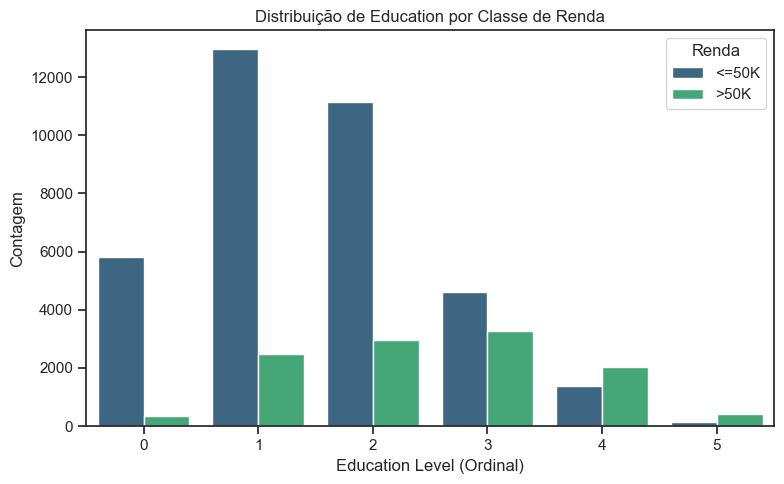

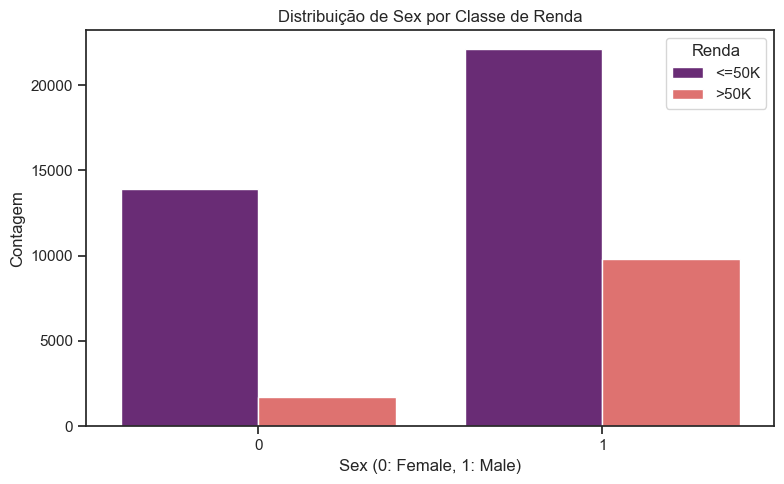

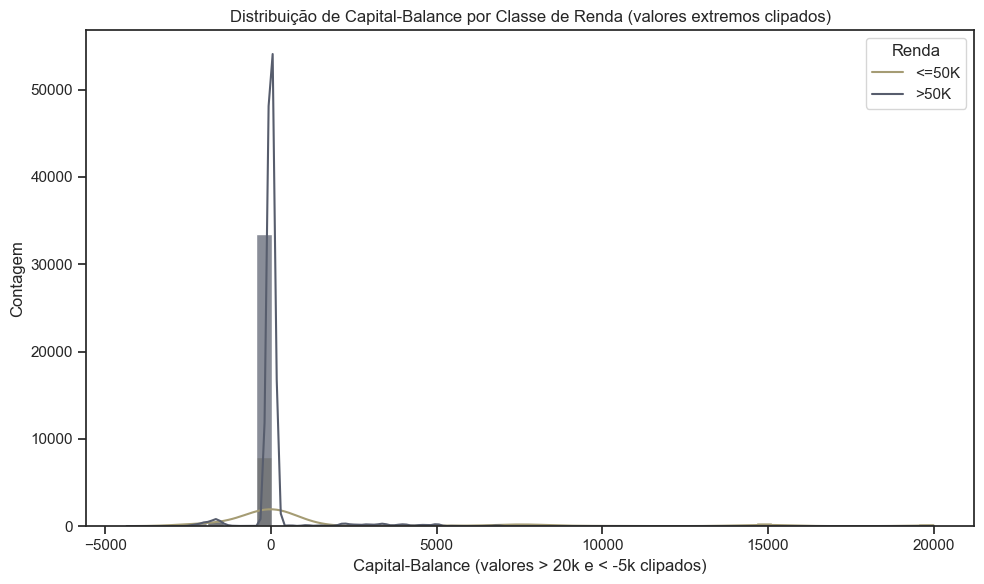

In [129]:

# Assuming df is the pre-processed DataFrame with selected features and _target_bin
selected_features = ['education', 'sex', 'capital-balance']

print("### Visualização das Features Selecionadas por Classe de Renda ###\n")

# Plot for 'education' (ordinal numerical)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='education', hue='_target_bin', palette='viridis')
plt.title('Distribuição de Education por Classe de Renda')
plt.xlabel('Education Level (Ordinal)')
plt.ylabel('Contagem')
plt.legend(title='Renda', labels=['<=50K', '>50K'])
plt.tight_layout()
plt.show()

# Plot for 'sex' (binary numerical)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='sex', hue='_target_bin', palette='magma')
plt.title('Distribuição de Sex por Classe de Renda')
plt.xlabel('Sex (0: Female, 1: Male)')
plt.ylabel('Contagem')
plt.legend(title='Renda', labels=['<=50K', '>50K'])
plt.tight_layout()
plt.show()

# Plot for 'capital-balance' (numerical)
# Capping upper values for better visualization, similar to previous EDA
cb_clip = df['capital-balance'].clip(lower=-5000, upper=20000)
plt.figure(figsize=(10, 6))
sns.histplot(data=df.assign(capital_balance_clip=cb_clip),
             x='capital_balance_clip', hue='_target_bin', bins=50,
             kde=True, stat='count', common_norm=False, alpha=0.7, palette='cividis')
plt.title('Distribuição de Capital-Balance por Classe de Renda (valores extremos clipados)')
plt.xlabel('Capital-Balance (valores > 20k e < -5k clipados)')
plt.ylabel('Contagem')
plt.legend(title='Renda', labels=['<=50K', '>50K'])
plt.tight_layout()
plt.show()


### Análise Detalhada das Features Selecionadas e do Algoritmo Branch and Bound

#### Features Selecionadas
O algoritmo Branch and Bound selecionou `education`, `sex` e `capital-balance` como o subconjunto ideal de features para maximizar a distância euclidiana entre os centróides das classes de renda (<=50K e >50K). Vamos analisar cada uma:

1.  **Education (Educação)**:
    *   **Insights dos Plots**: O plot de distribuição mostra claramente que à medida que o nível de educação aumenta (valores ordinais maiores), a proporção de indivíduos com renda >50K cresce significativamente. Níveis mais baixos de educação (dropout, HighGrad) têm uma predominância esmagadora da classe <=50K. Isso confirma a educação como um forte preditor de renda, e a codificação ordinal capturou bem essa relação.
    *   **Contribuição para a Distância**: A diferença nas médias de `education` entre as classes de renda é substancial, contribuindo grandemente para a separação dos centróides.

2.  **Sex (Gênero)**:
    *   **Insights dos Plots**: O gráfico mostra uma disparidade notável: a proporção de homens (1) com renda >50K é visivelmente maior do que a de mulheres (0). Embora ambos os gêneros tenham mais indivíduos na classe <=50K, a diferença percentual é mais acentuada para a classe de renda mais alta.
    *   **Contribuição para a Distância**: Essa diferença na distribuição entre os gêneros adiciona uma dimensão importante à separação dos centróides, mesmo sendo uma feature binária.

3.  **Capital-Balance (Saldo de Capital)**:
    *   **Insights dos Plots**: O histograma mostra que a vasta maioria dos indivíduos tem um `capital-balance` de 0 (ou próximo de 0). No entanto, para a classe >50K, há uma cauda mais longa e valores positivos de `capital-balance` são mais frequentes, embora ainda esparsos, em comparação com a classe <=50K. A densidade de pessoas com `capital-balance` positivo (ganhos de capital) é maior entre os que ganham >50K. A cauda de valores negativos (perdas de capital) é pequena em ambas as classes, mas ligeiramente mais pronunciada na classe de baixa renda.
    *   **Contribuição para a Distância**: Embora a maioria dos valores seja zero, a presença de ganhos de capital significativos para a classe de alta renda puxa o centróide dessa classe em uma direção que aumenta a distância, especialmente após a remoção de outliers e a agregação de capital-gain e capital-loss.

#### Efetividade do Branch and Bound

*   **Eficiência**: O Branch and Bound é uma técnica poderosa para problemas de otimização combinatória. Neste caso, ao contrário de uma busca exaustiva (que seria inviável para um grande número de features), ele consegue podar ramos da árvore de busca que não podem levar a uma solução melhor do que a já encontrada. Isso torna o processo muito mais eficiente.
*   **Otimização Local vs. Global**: O algoritmo busca a solução globalmente ótima (o maior score de distância euclidiana) dentro do espaço de busca definido, garantindo que o subconjunto encontrado é o melhor possível para a função de avaliação dada.
*   **Função de Avaliação**: A escolha da distância euclidiana entre centróides é uma métrica intuitiva para medir a separabilidade das classes. A maximização dessa distância diretamente visa encontrar features que melhor discriminam entre os grupos, o que é um objetivo comum na seleção de features para problemas de classificação.

#### Insights Ganhos

*   **Relevância de Features**: As features selecionadas (`education`, `sex`, `capital-balance`) são, de fato, variáveis intuitivamente fortes para prever a renda, o que valida a abordagem do Branch and Bound e a função de avaliação. Essas features capturam aspectos econômicos (capital-balance), sociais (educação) e demográficos (sexo) que são conhecidamente influentes na determinação da renda.
*   **Redução de Dimensionalidade**: O algoritmo demonstrou ser capaz de identificar um subconjunto conciso e poderoso (apenas 3 features de um total de 93 features codificadas) para explicar a separação entre as classes de renda. Isso não só simplifica modelos futuros, mas também melhora a interpretabilidade.
*   **Processamento de Dados Importante**: A fase de pré-processamento e feature engineering (como a binarização de `capital-balance` e a codificação ordinal de `education`) foi crucial para que essas features pudessem ser efetivamente utilizadas e avaliadas pelo algoritmo.

### Análise Detalhada das Features Selecionadas e do Algoritmo Branch and Bound

#### Features Selecionadas
O algoritmo Branch and Bound selecionou `education`, `sex` e `capital-balance` como o subconjunto ideal de features para maximizar a distância euclidiana entre os centróides das classes de renda (<=50K e >50K). Vamos analisar cada uma:

1.  **Education (Educação)**:
    *   **Insights dos Plots**: O plot de distribuição mostra claramente que à medida que o nível de educação aumenta (valores ordinais maiores), a proporção de indivíduos com renda >50K cresce significativamente. Níveis mais baixos de educação (dropout, HighGrad) têm uma predominância esmagadora da classe <=50K. Isso confirma a educação como um forte preditor de renda, e a codificação ordinal capturou bem essa relação.
    *   **Contribuição para a Distância**: A diferença nas médias de `education` entre as classes de renda é substancial, contribuindo grandemente para a separação dos centróides.

2.  **Sex (Gênero)**:
    *   **Insights dos Plots**: O gráfico mostra uma disparidade notável: a proporção de homens (1) com renda >50K é visivelmente maior do que a de mulheres (0). Embora ambos os gêneros tenham mais indivíduos na classe <=50K, a diferença percentual é mais acentuada para a classe de renda mais alta.
    *   **Contribuição para a Distância**: Essa diferença na distribuição entre os gêneros adiciona uma dimensão importante à separação dos centróides, mesmo sendo uma feature binária.

3.  **Capital-Balance (Saldo de Capital)**:
    *   **Insights dos Plots**: O histograma mostra que a vasta maioria dos indivíduos tem um `capital-balance` de 0 (ou próximo de 0). No entanto, para a classe >50K, há uma cauda mais longa e valores positivos de `capital-balance` são mais frequentes, embora ainda esparsos, em comparação com a classe <=50K. A densidade de pessoas com `capital-balance` positivo (ganhos de capital) é maior entre os que ganham >50K. A cauda de valores negativos (perdas de capital) é pequena em ambas as classes, mas ligeiramente mais pronunciada na classe de baixa renda.
    *   **Contribuição para a Distância**: Embora a maioria dos valores seja zero, a presença de ganhos de capital significativos para a classe de alta renda puxa o centróide dessa classe em uma direção que aumenta a distância, especialmente após a remoção de outliers e a agregação de capital-gain e capital-loss.

#### Efetividade do Branch and Bound

*   **Eficiência**: O Branch and Bound é uma técnica poderosa para problemas de otimização combinatória. Neste caso, ao contrário de uma busca exaustiva (que seria inviável para um grande número de features), ele consegue podar ramos da árvore de busca que não podem levar a uma solução melhor do que a já encontrada. Isso torna o processo muito mais eficiente.
*   **Otimização Local vs. Global**: O algoritmo busca a solução globalmente ótima (o maior score de distância euclidiana) dentro do espaço de busca definido, garantindo que o subconjunto encontrado é o melhor possível para a função de avaliação dada.
*   **Função de Avaliação**: A escolha da distância euclidiana entre centróides é uma métrica intuitiva para medir a separabilidade das classes. A maximização dessa distância diretamente visa encontrar features que melhor discriminam entre os grupos, o que é um objetivo comum na seleção de features para problemas de classificação.

#### Insights Ganhos

*   **Relevância de Features**: As features selecionadas (`education`, `sex`, `capital-balance`) são, de fato, variáveis intuitivamente fortes para prever a renda, o que valida a abordagem do Branch and Bound e a função de avaliação. Essas features capturam aspectos econômicos (capital-balance), sociais (educação) e demográficos (sexo) que são conhecidamente influentes na determinação da renda.
*   **Redução de Dimensionalidade**: O algoritmo demonstrou ser capaz de identificar um subconjunto conciso e poderoso (apenas 3 features de um total de 93 features codificadas) para explicar a separação entre as classes de renda. Isso não só simplifica modelos futuros, mas também melhora a interpretabilidade.
*   **Processamento de Dados Importante**: A fase de pré-processamento e feature engineering (como a binarização de `capital-balance` e a codificação ordinal de `education`) foi crucial para que essas features pudessem ser efetivamente utilizadas e avaliadas pelo algoritmo.


# Análise PCA

## Preparar dataset para PCA

- Repetir a etapa de feature engineering realizada, voltando atrás nas discretizações
- Aplicar StandardScaler
- Medir Correlação entre as variáveis
- Remover os outliers que for possível

In [130]:

# Re-fetch dataset and initial df (from cell 7LxHUIwksjfG and L6jYCjFU0gMb)
adult = fetch_ucirepo(id=2)
X_initial_fetch = adult.data.features
y_initial_fetch = adult.data.targets
df = pd.concat([X_initial_fetch, y_initial_fetch], axis=1)

# --- Start of Cleaning (from cell m5R_uhQIyTno onwards) ---
# Target standardization
df['income'] = df['income'].astype(str).str.replace('.', '', regex=False).str.strip()

# Replace '?' with NaN in relevant columns (from EDA analysis like HXz2qhZi4-Mi)
for col in ['workclass', 'occupation', 'native-country']:
    if col in df.columns and df[col].dtype == 'object':
        df[col] = df[col].replace('?', np.nan)

# Missing values removal (from AySKx8Eth-Vs)
df = df.dropna()

# Duplicate removal (from m2Pt_Fhlh-Vt)
df = df.drop_duplicates()

# Inconsistency removal (from w1itaZ2tsbT6)
features_preditoras_temp = list(df.columns.drop('income'))
contagem_rotulos = df.groupby(features_preditoras_temp)['income'].transform('nunique')
df = df[contagem_rotulos == 1]
# --- End of Cleaning ---

# --- Start of Feature Engineering (from Is1aASpuh-Vu onwards) ---
# Agrupamento de níveis de education
edu_map = {
    'Preschool': 'dropout', '1st-4th': 'dropout', '5th-6th': 'dropout',
    '7th-8th': 'dropout', '9th': 'dropout', '10th': 'dropout',
    '11th': 'dropout', '12th': 'dropout', 'HS-Grad': 'HighGrad',
    'HS-grad': 'HighGrad', 'Some-college': 'CommunityCollege',
    'Assoc-acdm': 'CommunityCollege', 'Assoc-voc': 'CommunityCollege',
    'Bachelors': 'Bachelors', 'Masters': 'Masters',
    'Prof-school': 'Masters', 'Doctorate': 'Doctorate',
}
df['education'] = df['education'].replace(edu_map)

# Média de education-num por categoria após o agrupamento (used to define order)
edu_mean = df[['education', 'education-num']].groupby(['education'], as_index=False).mean().sort_values(by='education-num', ascending=True)

# OrdinalEncoder em education com ordem baseada em education-num
edu_order = edu_mean['education'].tolist()
edu_encoder = OrdinalEncoder(categories=[edu_order])
df['education'] = edu_encoder.fit_transform(df[['education']]).astype(int)

# Drop education-num (from 6hWLh0fsh-Vu)
df = df.drop(columns=['education-num'])

# Drop de fnlwgt (from UjZDM_8Rh-Vu)
df = df.drop(columns=['fnlwgt'])

# Label encoding para sex (from ZFdtUhQoh-Vu)
df['sex'] = pd.Categorical(df['sex']).codes


# Agrupamento de marital-status (from _Ku8-xmbh-Vu)
marital_map = {
    'Never-married': 'NotMarried', 'Married-AF-spouse': 'Married',
    'Married-civ-spouse': 'Married', 'Married-spouse-absent': 'NotMarried',
    'Separated': 'Separated', 'Divorced': 'Separated', 'Widowed': 'Widowed',
}
df['marital-status'] = df['marital-status'].replace(marital_map)


# Feature: capital-balance (from rAIcfandh-Vu)
# Ensure capital-gain and capital-loss columns exist before calculating capital-balance
if 'capital-gain' in df.columns and 'capital-loss' in df.columns:
    df['capital-balance'] = df['capital-gain'] - df['capital-loss']
# Drop original capital-gain and capital-loss only if they exist and capital-balance was created
if 'capital-balance' in df.columns:
    df = df.drop(columns=['capital-gain', 'capital-loss'])
# --- End of Feature Engineering ---

# --- Start of One-Hot Encoding (from HCJqqgIxh-Vu onwards) ---
ohe_cols = ['marital-status', 'relationship', 'race', 'native-country', 'occupation', 'workclass']
df = pd.get_dummies(df, columns=ohe_cols, prefix=ohe_cols, drop_first=False)

# Target binarization (from cRtzpWT7h-Vu)
target_col = 'income' # Original target name
df[target_col] = df[target_col].astype(str).str.strip().str.replace('.', '', regex=False)
vals = sorted(df[target_col].dropna().unique())
target_positive = '>50K' # Based on previous output
df['_target_bin'] = (df[target_col] == target_positive).astype(int)
df = df.drop(columns=[target_col])

# Column reordering (from BAc8a4Pah-Vu)
cols = [c for c in df.columns if c != '_target_bin'] + ['_target_bin']
df = df[cols]
# --- End of One-Hot Encoding and final df preparation ---

# --- Original code from cell 875a0451 starts here ---
print("### 1. Primeiras linhas do DataFrame 'df' (após feature engineering e encoding):\n")
display(df.head())

# 2. Criar X (features) e y (target)
X = df.drop(columns=['_target_bin'])
y = df['_target_bin']

print("\n### 3. Formato dos DataFrames X e y após a separação:\n")
print(f"Shape de X (features): {X.shape}")
print(f"Shape de y (target): {y.shape}")

### 1. Primeiras linhas do DataFrame 'df' (após feature engineering e encoding):



,age,education,sex,hours-per-week,capital-balance,marital-status_Married,marital-status_NotMarried,marital-status_Separated,marital-status_Widowed,relationship_Husband,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White,native-country_?,native-country_Cambodia,native-country_Canada,native-country_China,native-country_Columbia,native-country_Cuba,native-country_Dominican-Republic,native-country_Ecuador,native-country_El-Salvador,native-country_England,native-country_France,native-country_Germany,native-country_Greece,native-country_Guatemala,native-country_Haiti,native-country_Holand-Netherlands,native-country_Honduras,native-country_Hong,native-country_Hungary,native-country_India,native-country_Iran,native-country_Ireland,native-country_Italy,native-country_Jamaica,native-country_Japan,native-country_Laos,native-country_Mexico,native-country_Nicaragua,native-country_Outlying-US(Guam-USVI-etc),native-country_Peru,native-country_Philippines,native-country_Poland,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,occupation_?,occupation_Adm-clerical,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,workclass_?,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,_target_bin
0,39,3,1,40,2174,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,0
1,50,3,1,13,0,True,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,0
2,38,1,1,40,0,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,0
3,53,0,1,40,0,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,0
4,28,3,0,40,0,True,False,False,False,False,False,False,False,False,T


### 3. Formato dos DataFrames X e y após a separação:

Shape de X (features): (47563, 86)
Shape de y (target): (47563,)


### Features Numéricas

In [131]:
# features numéricas
features_numericas = X.select_dtypes(include=['number']).columns.tolist()
features_numericas

['age', 'education', 'sex', 'hours-per-week', 'capital-balance']

### PCA com Todas as Features


In [132]:
# X com todas as features (sem o target)
X_pca = df.drop(columns=['_target_bin'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)
X_scaled_df = pd.DataFrame(X_scaled, columns=X_pca.columns)

print(f'X_pca: {X_pca.shape} | X_scaled: {X_scaled_df.shape}')


X_pca: (47563, 86) | X_scaled: (47563, 86)


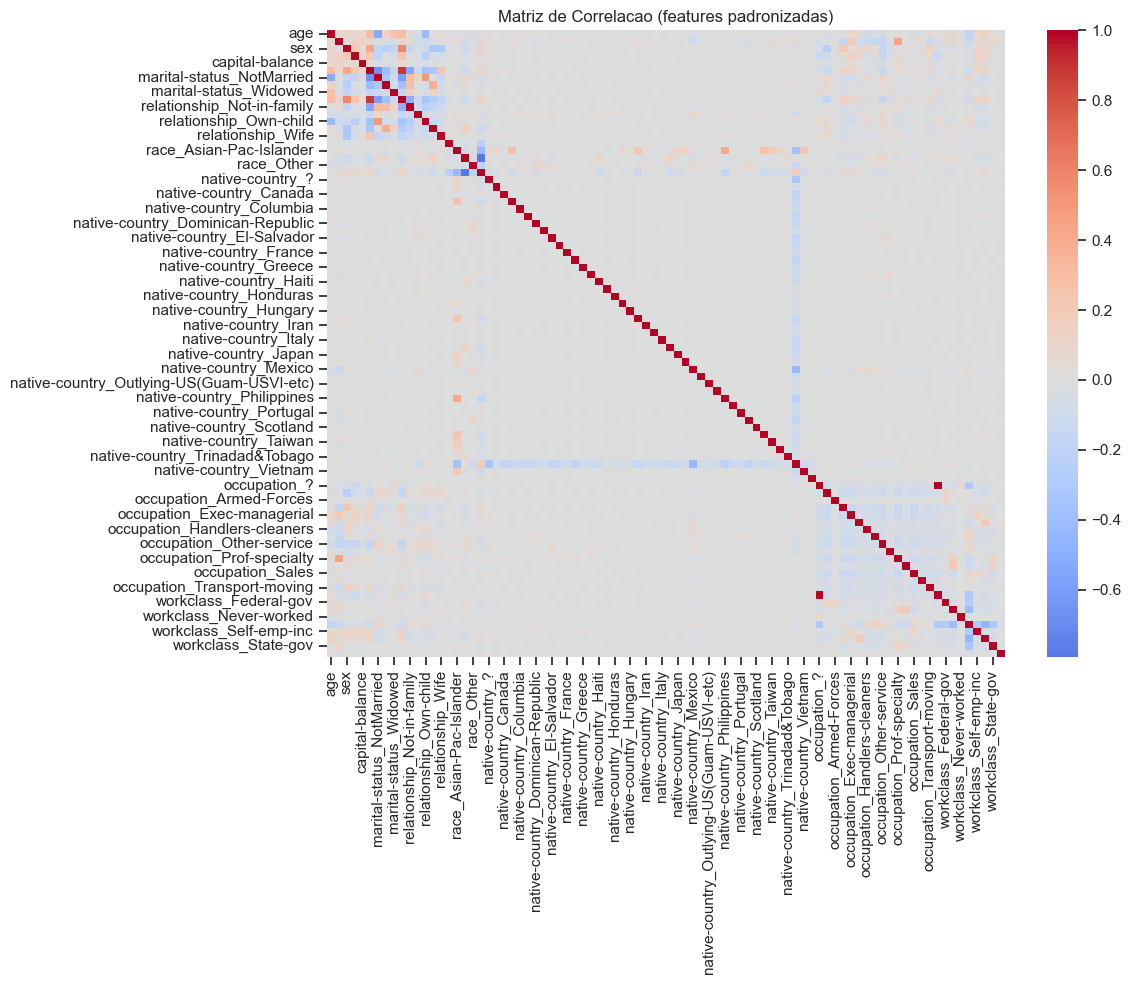

In [133]:
# Matriz de correlacao das features padronizadas
corr = X_scaled_df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Matriz de Correlacao (features padronizadas)')
plt.tight_layout()
plt.show()


In [134]:
# PCA em todas as features
pca = PCA(random_state=42)
pcs = pca.fit_transform(X_scaled_df)
pc_cols = [f'PC{i+1}' for i in range(pcs.shape[1])]
pca_df = pd.DataFrame(pcs, columns=pc_cols)
pca_df['_target_bin'] = df['_target_bin'].values


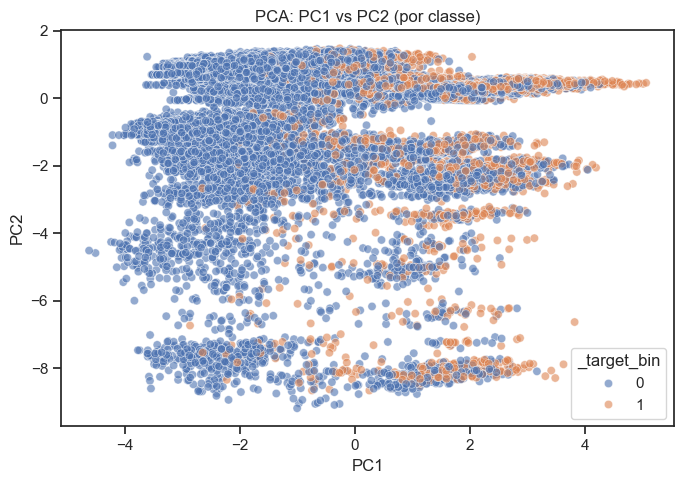

In [135]:
# Plot dos PCs (PC1 x PC2)
plt.figure(figsize=(7, 5))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='_target_bin', alpha=0.6)
plt.title('PCA: PC1 vs PC2 (por classe)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()


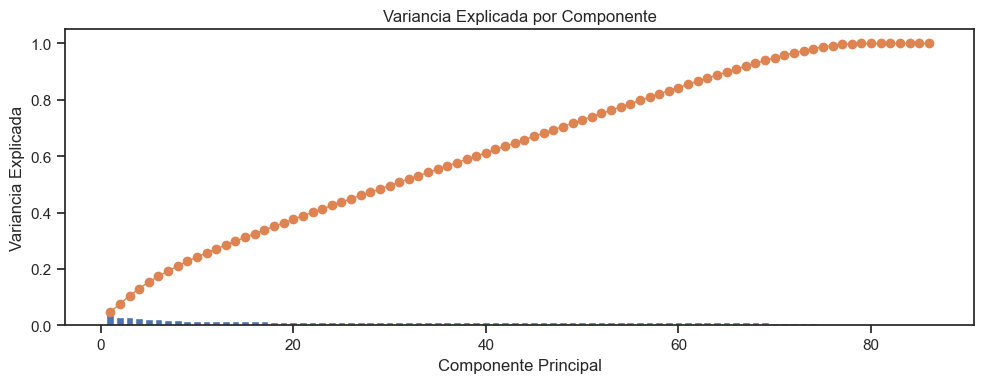

,PC,variancia_explicada
0,PC1,0.046723
1,PC2,0.029244
2,PC3,0.028143
3,PC4,0.026012
4,PC5,0.023063
5,PC6,0.020734
6,PC7,0.018396
7,PC8,0.017731
8,PC9,0.016396
9,PC10,0.015582


In [136]:
# Variancia explicada de cada componente
explained = pca.explained_variance_ratio_
plt.figure(figsize=(10, 4))
plt.bar(range(1, len(explained) + 1), explained, color='#4C72B0')
plt.plot(range(1, len(explained) + 1), np.cumsum(explained), color='#DD8452', marker='o', linewidth=1)
plt.title('Variancia Explicada por Componente')
plt.xlabel('Componente Principal')
plt.ylabel('Variancia Explicada')
plt.tight_layout()
plt.show()

explained_df = pd.DataFrame({'PC': pc_cols, 'variancia_explicada': explained})
explained_df.head(10)
